# Measuring arc spectra

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import lmfit
from lmfit import minimize, Parameters
from astropy.io import fits

import uncertainties.umath as uum
from uncertainties import ufloat
from uncertainties import unumpy as upy

import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

from magE.directMethod import directT, run_all
from magE.functions import mergeSpec, gaussian, to_vel, FWHM, dV, save_catalog
from magE.plotutils import * 
from magE.constutils import *

PATH = '/home/benjamin/Documents/analogs/specs/final_spec/'
os.chdir(PATH)
os.getcwd()

'/home/benjamin/Documents/analogs/specs/final_spec'

In [2]:
# For intrinsic broadening
# 19A night does not have blue reduction, only red
wcal_red = fits.open('/home/benjamin/Documents/pypeit19a/redux_J0950/red/magellan_mage_A/Calibrations/WaveCalib_A_0_DET01.fits')

---

# Two component model fit for [OIII] 4959

In [5]:
wcal_red.info()

Filename: /home/benjamin/Documents/pypeit19a/redux_J0950/red/magellan_mage_A/Calibrations/WaveCalib_A_0_DET01.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      13   ()      
  1  SPAT_IDS      1 ImageHDU        26   (10,)   int64   
  2  ECH_ORDERS    1 ImageHDU        22   (10,)   int64   
  3  SPAT_ID-491_WAVEFIT    1 BinTableHDU     41   1R x 6C   [73D, 73D, 73J, 2048D, 2048D, 88D]   
  4  SPAT_ID-491_PYPEITFIT    1 BinTableHDU     36   1R x 6C   [73D, 73D, 1K, 73D, 5D, 73K]   
  5  SPAT_ID-563_WAVEFIT    1 BinTableHDU     41   1R x 6C   [90D, 90D, 90J, 2048D, 2048D, 104D]   
  6  SPAT_ID-563_PYPEITFIT    1 BinTableHDU     36   1R x 6C   [90D, 90D, 1K, 90D, 5D, 90K]   
  7  SPAT_ID-629_WAVEFIT    1 BinTableHDU     41   1R x 6C   [88D, 88D, 88J, 2048D, 2048D, 107D]   
  8  SPAT_ID-629_PYPEITFIT    1 BinTableHDU     36   1R x 6C   [88D, 88D, 1K, 88D, 5D, 88K]   
  9  SPAT_ID-690_WAVEFIT    1 BinTableHDU     41   1R x 6C   [83D, 83D

(0.0, 2000.0)

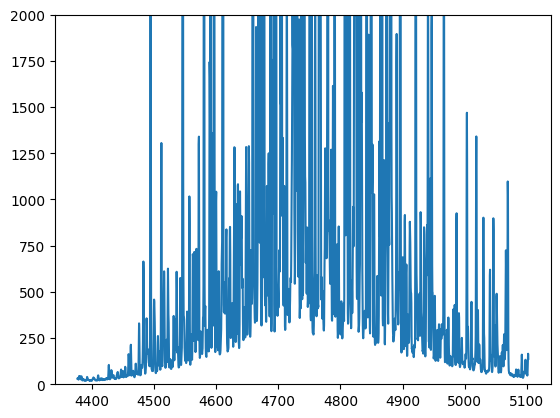

In [6]:
plt.plot(wcal_red[7].data['wave_soln'][0], wcal_red[7].data['spec'][0])
#plt.xlim(7740, 7770)
plt.ylim(0, 2000)

# [OIII]4959

### Arc lines

In [7]:
wave_cat['[OIII]4959']*(1 + z_BN[igal])

5445.057839885

In [8]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_4959 = [wave_cat['[OIII]4959']*(1 + z_BN[igal]) - 10, wave_cat['[OIII]4959']*(1 + z_BN[igal]) + 10]
mask_arc_4959 = (wcal_red[11].data['wave_soln'][0] >= wlims_4959[0]) & (wcal_red[11].data['wave_soln'][0] < wlims_4959[1])

# Arc spectra around the fitted line
x_arc_4959 = wcal_red[11].data['wave_soln'][0][mask_arc_4959]
y_arc_4959 = wcal_red[11].data['spec'][0][mask_arc_4959]

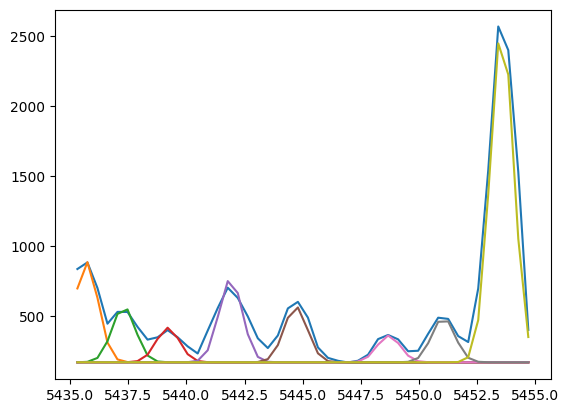

In [9]:
plt.plot(x_arc_4959, y_arc_4959)
plt.plot(x_arc_4959, 170 + gaussian(x_arc_4959,  900,  5435.7, 0, 0.5))
plt.plot(x_arc_4959, 170 + gaussian(x_arc_4959,  500,  5437.3, 0, 0.5))
plt.plot(x_arc_4959, 170 + gaussian(x_arc_4959,  310,  5439.2, 0, 0.5))
plt.plot(x_arc_4959, 170 + gaussian(x_arc_4959,  750,  5441.9, 0, 0.5))
plt.plot(x_arc_4959, 170 + gaussian(x_arc_4959,  500,  5444.7, 0, 0.5))
plt.plot(x_arc_4959, 170 + gaussian(x_arc_4959,  240,  5448.7, 0, 0.5))
plt.plot(x_arc_4959, 170 + gaussian(x_arc_4959,  400, 5451.05, 0, 0.5))
plt.plot(x_arc_4959, 170 + gaussian(x_arc_4959, 3000, 5453.57, 0, 0.5))

In [10]:
params_arc_4959 = Parameters()
params_arc_4959.add('z', value=0.0, vary=False)
params_arc_4959.add('mu1', value= 5435.7, vary=False)
params_arc_4959.add('mu2', value= 5437.3, vary=False)
params_arc_4959.add('mu3', value= 5439.2, vary=False)
params_arc_4959.add('mu4', value= 5441.9, vary=False)
params_arc_4959.add('mu5', value= 5444.7, vary=False)
params_arc_4959.add('mu6', value= 5448.7, vary=False)
params_arc_4959.add('mu7', value=5451.05, vary=False)
params_arc_4959.add('mu8', value=5453.57, vary=False)
params_arc_4959.add('arc1', value= 900, min=0.)
params_arc_4959.add('arc2', value= 500, min=0.)
params_arc_4959.add('arc3', value= 310, min=0.)
params_arc_4959.add('arc4', value= 750, min=0.)
params_arc_4959.add('arc5', value= 500, min=0.)
params_arc_4959.add('arc6', value= 240, min=0.)
params_arc_4959.add('arc7', value= 400, min=0.)
params_arc_4959.add('arc8', value=3000, min=0.)
params_arc_4959.add('sigma', value=0.5, min=0.)
params_arc_4959.add('bkg', value=170, vary=True)

def residual_arc_4959(params_arc_4959, x, data, uncertainty):
    
    z = params_arc_4959['z']
    mu1 = params_arc_4959['mu1']
    mu2 = params_arc_4959['mu2']
    mu3 = params_arc_4959['mu3']
    mu4 = params_arc_4959['mu4']
    mu5 = params_arc_4959['mu5']
    mu6 = params_arc_4959['mu6']
    mu7 = params_arc_4959['mu7']
    mu8 = params_arc_4959['mu8']
    flux1 = params_arc_4959['arc1']
    flux2 = params_arc_4959['arc2']
    flux3 = params_arc_4959['arc3']
    flux4 = params_arc_4959['arc4']
    flux5 = params_arc_4959['arc5']
    flux6 = params_arc_4959['arc6']
    flux7 = params_arc_4959['arc7']
    flux8 = params_arc_4959['arc8']
    sigma = params_arc_4959['sigma']
    bkg = params_arc_4959['bkg']
    
    x = x_arc_4959
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model6 = gaussian(x, flux6, mu6, z, sigma)
    model7 = gaussian(x, flux7, mu7, z, sigma)
    model8 = gaussian(x, flux8, mu8, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5 + model6 + model7 + model8
    return (model - y_arc_4959) / (0.05 * np.max(y_arc_4959))

np.random.seed(950)
out_arc_4959 = minimize(residual_arc_4959, params_arc_4959, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [00:53<00:00, 46.97it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 10 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [81.13514399 79.08769441 83.12400306 81.92415641 80.77968129 86.26230589
 87.75931718 78.83725265 83.00905749 77.85337227]


In [11]:
out_arc_4959.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,5435.70000,,,5435.7,-inf,inf,False
mu2,5437.30000,,,5437.3,-inf,inf,False
mu3,5439.20000,,,5439.2,-inf,inf,False
mu4,5441.90000,,,5441.9,-inf,inf,False
mu5,5444.70000,,,5444.7,-inf,inf,False
mu6,5448.70000,,,5448.7,-inf,inf,False
mu7,5451.05000,,,5451.05,-inf,inf,False
mu8,5453.57000,,,5453.57,-inf,inf,False
arc1,1036.22089,162.411937,(15.67%),900,0.00000000,inf,True


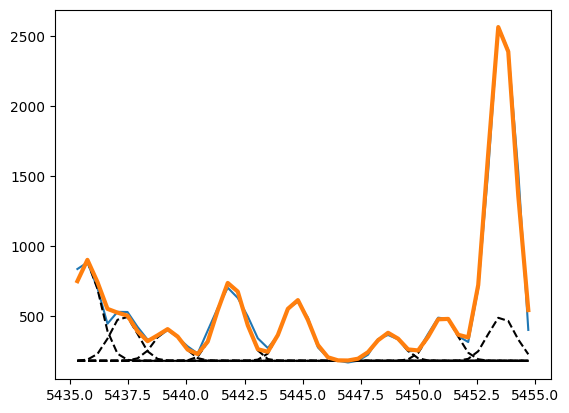

In [12]:
arc1_4959 = out_arc_4959.flatchain.arc1.mean()
arc2_4959 = out_arc_4959.flatchain.arc2.mean()
arc3_4959 = out_arc_4959.flatchain.arc3.mean()
arc4_4959 = out_arc_4959.flatchain.arc4.mean()
arc5_4959 = out_arc_4959.flatchain.arc5.mean()
arc6_4959 = out_arc_4959.flatchain.arc6.mean()
arc7_4959 = out_arc_4959.flatchain.arc7.mean()
arc8_4959 = out_arc_4959.flatchain.arc8.mean()

sigma_arc_4959 = out_arc_4959.flatchain.sigma.mean()
bkg_arc_4959 = out_arc_4959.flatchain.bkg.mean()

plt.plot(x_arc_4959, y_arc_4959)

plt.plot(x_arc_4959, bkg_arc_4959 + gaussian(x_arc_4959, arc1_4959,  5435.7, 0, sigma_arc_4959), ls='--', color='black')
plt.plot(x_arc_4959, bkg_arc_4959 + gaussian(x_arc_4959, arc2_4959,  5437.3, 0, sigma_arc_4959), ls='--', color='black')
plt.plot(x_arc_4959, bkg_arc_4959 + gaussian(x_arc_4959, arc3_4959,  5439.2, 0, sigma_arc_4959), ls='--', color='black')
plt.plot(x_arc_4959, bkg_arc_4959 + gaussian(x_arc_4959, arc4_4959,  5441.9, 0, sigma_arc_4959), ls='--', color='black')
plt.plot(x_arc_4959, bkg_arc_4959 + gaussian(x_arc_4959, arc5_4959,  5444.7, 0, sigma_arc_4959), ls='--', color='black')
plt.plot(x_arc_4959, bkg_arc_4959 + gaussian(x_arc_4959, arc6_4959,  5448.7, 0, sigma_arc_4959), ls='--', color='black')
plt.plot(x_arc_4959, bkg_arc_4959 + gaussian(x_arc_4959, arc7_4959, 5451.05, 0, sigma_arc_4959), ls='--', color='black')
plt.plot(x_arc_4959, bkg_arc_4959 + gaussian(x_arc_4959, arc7_4959, 5453.57, 0, sigma_arc_4959), ls='--', color='black')

plt.plot(x_arc_4959, bkg_arc_4959 + gaussian(x_arc_4959, arc1_4959,  5435.7, 0, sigma_arc_4959) \
                                  + gaussian(x_arc_4959, arc2_4959,  5437.3, 0, sigma_arc_4959) \
                                  + gaussian(x_arc_4959, arc3_4959,  5439.2, 0, sigma_arc_4959) \
                                  + gaussian(x_arc_4959, arc4_4959,  5441.9, 0, sigma_arc_4959) \
                                  + gaussian(x_arc_4959, arc5_4959,  5444.7, 0, sigma_arc_4959) \
                                  + gaussian(x_arc_4959, arc6_4959,  5448.7, 0, sigma_arc_4959) \
                                  + gaussian(x_arc_4959, arc7_4959, 5451.05, 0, sigma_arc_4959) \
                                  + gaussian(x_arc_4959, arc8_4959, 5453.57, 0, sigma_arc_4959), lw=3
)

---

# [NII]6548 + H$\alpha$ + [NII]6584

### Arc lines

In [25]:
wave_cat['Ha']*(1 + z_BN[igal])

7206.173117650001

In [26]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_ha = [wave_cat['Ha']*(1 + z_BN[igal]) - 10, wave_cat['Ha']*(1 + z_BN[igal]) + 10]
mask_arc_ha = (wcal_red[17].data['wave_soln'][0] >= wlims_ha[0]) & (wcal_red[17].data['wave_soln'][0] < wlims_ha[1])

# Arc spectra around the fitted line
x_arc_ha = wcal_red[17].data['wave_soln'][0][mask_arc_ha]
y_arc_ha = wcal_red[17].data['spec'][0][mask_arc_ha]

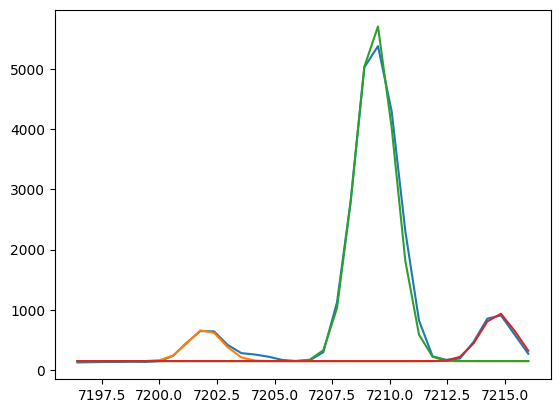

In [27]:
plt.plot(x_arc_ha, y_arc_ha)
plt.plot(x_arc_ha, 150 + gaussian(x_arc_ha,  1000,   7202, 0, 0.75))
plt.plot(x_arc_ha, 150 + gaussian(x_arc_ha, 12000, 7209.35, 0, 0.85))
plt.plot(x_arc_ha, 150 + gaussian(x_arc_ha,  1500, 7214.7, 0, 0.75))

In [28]:
params_arc_ha = Parameters()
params_arc_ha.add('z', value=0.0, vary=False)
params_arc_ha.add('mu1', value=   7202, vary=False)
params_arc_ha.add('mu2', value=7209.35, vary=False)
params_arc_ha.add('mu3', value= 7214.7, vary=False)
params_arc_ha.add('arc1', value= 1000, min=0.)
params_arc_ha.add('arc2', value=10000, min=0.)
params_arc_ha.add('arc3', value= 1500, min=0.)
params_arc_ha.add('sigma', value=0.8, min=0.)
params_arc_ha.add('bkg', value=150, vary=True)

def residual_arc_ha(params_arc_ha, x, data, uncertainty):
    
    z = params_arc_ha['z']
    mu1 = params_arc_ha['mu1']
    mu2 = params_arc_ha['mu2']
    mu3 = params_arc_ha['mu3']
    flux1 = params_arc_ha['arc1']
    flux2 = params_arc_ha['arc2']
    flux3 = params_arc_ha['arc3']
    sigma = params_arc_ha['sigma']
    bkg = params_arc_ha['bkg']
    
    x = x_arc_ha
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = bkg + model1 + model2 + model3
    return (model - y_arc_ha) / (0.05 * np.max(y_arc_ha))

np.random.seed(950)
out_arc_ha = minimize(residual_arc_ha, params_arc_ha, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [00:48<00:00, 51.19it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [48.54542872 52.27158294 46.85712354 49.78357913 48.54609671]


In [29]:
out_arc_ha.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,7202.00000,,,7202,-inf,inf,False
mu2,7209.35000,,,7209.35,-inf,inf,False
mu3,7214.70000,,,7214.7,-inf,inf,False
arc1,1267.43350,458.004700,(36.14%),1000,0.00000000,inf,True
arc2,12718.5237,593.711548,(4.67%),10000,0.00000000,inf,True
arc3,1739.86259,443.601090,(25.50%),1500,0.00000000,inf,True
sigma,0.93066510,0.04236101,(4.55%),0.8,0.00000000,inf,True
bkg,114.939099,72.7921883,(63.33%),150,-inf,inf,True


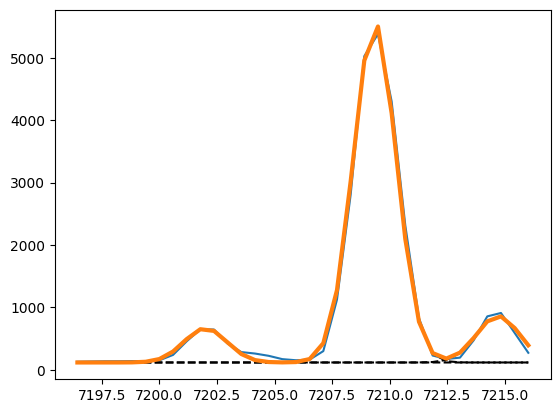

In [30]:
arc1_ha = out_arc_ha.flatchain.arc1.mean()
arc2_ha = out_arc_ha.flatchain.arc2.mean()
arc3_ha = out_arc_ha.flatchain.arc3.mean()
sigma_arc_ha = out_arc_ha.flatchain.sigma.mean()
bkg_arc_ha = out_arc_ha.flatchain.bkg.mean()

plt.plot(x_arc_ha, y_arc_ha)

plt.plot(x_arc_ha, bkg_arc_ha + gaussian(x_arc_ha, arc1_ha,    7202, 0, sigma_arc_ha), ls='--', color='black')
plt.plot(x_arc_ha, bkg_arc_ha + gaussian(x_arc_ha, arc2_ha, 7209.35, 0, sigma_arc_ha), ls='--', color='black')
plt.plot(x_arc_ha, bkg_arc_ha + gaussian(x_arc_ha, arc3_ha,  7214.7, 0, sigma_arc_ha), ls='--', color='black')

plt.plot(x_arc_ha, bkg_arc_ha + gaussian(x_arc_ha, arc1_ha,    7202, 0, sigma_arc_ha) \
                              + gaussian(x_arc_ha, arc2_ha, 7209.35, 0, sigma_arc_ha) \
                              + gaussian(x_arc_ha, arc3_ha,  7214.7, 0, sigma_arc_ha), lw=3
)

# [OII]7319 + [OII]7330

### Arc lines

In [39]:
wave_cat['[OII]7330']*(1 + z_BN[igal])

8048.80517665

In [40]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_7330 = [wave_cat['[OII]7330']*(1 + z_BN[igal]) - 10, wave_cat['[OII]7330']*(1 + z_BN[igal]) + 10]
mask_arc_7330 = (wcal_red[17].data['wave_soln'][0] >= wlims_7330[0]) & (wcal_red[17].data['wave_soln'][0] < wlims_7330[1])

# Arc spectra around the fitted line
x_arc_7330 = wcal_red[17].data['wave_soln'][0][mask_arc_7330]
y_arc_7330 = wcal_red[17].data['spec'][0][mask_arc_7330]

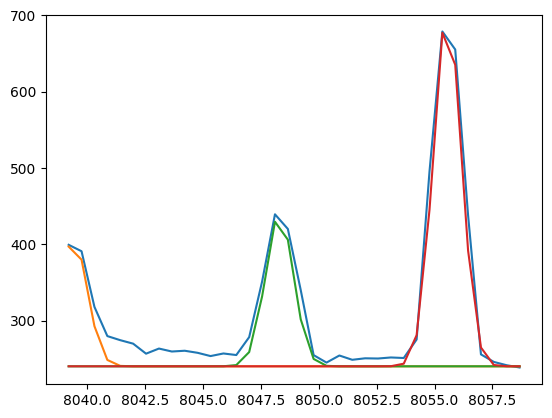

In [41]:
plt.plot(x_arc_7330, y_arc_7330)
plt.plot(x_arc_7330, 240 + gaussian(x_arc_7330, 250, 8039.4, 0, 0.6))
plt.plot(x_arc_7330, 240 + gaussian(x_arc_7330, 300, 8048.3, 0, 0.6))
plt.plot(x_arc_7330, 240 + gaussian(x_arc_7330, 700, 8055.55, 0, 0.6))

In [42]:
params_arc_7330 = Parameters()
params_arc_7330.add('z', value=0.0, vary=False)
params_arc_7330.add('mu1', value= 8039.4, vary=True)
params_arc_7330.add('mu2', value= 8048.3, vary=True)
params_arc_7330.add('mu3', value=8055.55, vary=True)
params_arc_7330.add('arc1', value=250, min=0.)
params_arc_7330.add('arc2', value=300, min=0.)
params_arc_7330.add('arc3', value=700, min=0.)
params_arc_7330.add('sigma', value=0.6, min=0.)
params_arc_7330.add('bkg', value=240, vary=True)

def residual_arc_7330(params_arc_7330, x, data, uncertainty):
    
    z = params_arc_7330['z']
    mu1 = params_arc_7330['mu1']
    mu2 = params_arc_7330['mu2']
    mu3 = params_arc_7330['mu3']
    flux1 = params_arc_7330['arc1']
    flux2 = params_arc_7330['arc2']
    flux3 = params_arc_7330['arc3']
    sigma = params_arc_7330['sigma']
    bkg = params_arc_7330['bkg']
    
    x = x_arc_7330
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = bkg + model1 + model2 + model3
    return (model - y_arc_7330) / (0.05 * np.max(y_arc_7330))

np.random.seed(950)
out_arc_7330 = minimize(residual_arc_7330, params_arc_7330, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [01:00<00:00, 41.59it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 8 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [80.19991071 68.35637675 65.7168187  79.3642242  75.69678145 84.4935123
 88.04164335 72.02043447]


In [43]:
out_arc_7330.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,8039.42648,0.22589805,(0.00%),8039.4,-inf,inf,True
mu2,8048.32285,0.11463862,(0.00%),8048.3,-inf,inf,True
mu3,8055.55646,0.04831815,(0.00%),8055.55,-inf,inf,True
arc1,257.447467,53.4070577,(20.74%),250,0.00000000,inf,True
arc2,317.160836,46.0192857,(14.51%),300,0.00000000,inf,True
arc3,742.576241,52.7808873,(7.11%),700,0.00000000,inf,True
sigma,0.64893285,0.04522180,(6.97%),0.6,0.00000000,inf,True
bkg,252.607861,7.73065117,(3.06%),240,-inf,inf,True


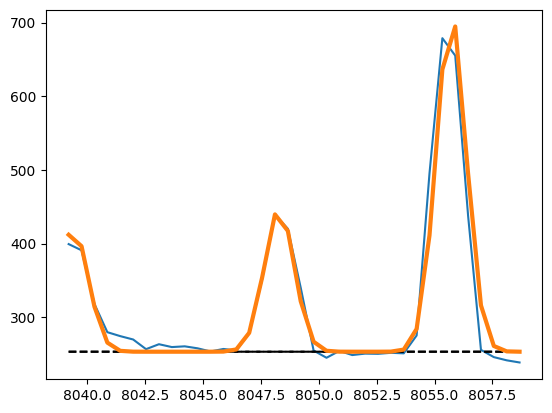

In [44]:
arc1_7330 = out_arc_7330.flatchain.arc1.mean()
arc2_7330 = out_arc_7330.flatchain.arc2.mean()
arc3_7330 = out_arc_7330.flatchain.arc3.mean()

mu1_7330 = out_arc_7330.flatchain.mu1.mean()
mu2_7330 = out_arc_7330.flatchain.mu2.mean()
mu3_7330 = out_arc_7330.flatchain.mu3.mean()

sigma_arc_7330 = out_arc_7330.flatchain.sigma.mean()
bkg_arc_7330 = out_arc_7330.flatchain.bkg.mean()

plt.plot(x_arc_7330, y_arc_7330)

plt.plot(x_arc_7330, bkg_arc_7330 + gaussian(x_arc_7330, arc1_7330, mu1_7330, 0, sigma_arc_7330), ls='--', color='black')
plt.plot(x_arc_7330, bkg_arc_7330 + gaussian(x_arc_7330, arc2_7330, mu2_7330, 0, sigma_arc_7330), ls='--', color='black')
plt.plot(x_arc_7330, bkg_arc_7330 + gaussian(x_arc_7330, arc3_7330, mu3_7330, 0, sigma_arc_7330), ls='--', color='black')

plt.plot(x_arc_7330, bkg_arc_7330 + gaussian(x_arc_7330, arc1_7330, mu1_7330, 0, sigma_arc_7330) \
                                  + gaussian(x_arc_7330, arc2_7330, mu2_7330, 0, sigma_arc_7330) \
                                  + gaussian(x_arc_7330, arc3_7330, mu3_7330, 0, sigma_arc_7330), lw=3
)

# HeI 7065

### Arc lines

In [53]:
wave_cat['HeI7065']*(1 + z_BN[igal])

7757.825901650001

In [54]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_7065 = [wave_cat['HeI7065']*(1 + z_BN[igal]) + 10, wave_cat['HeI7065']*(1 + z_BN[igal]) + 30]
mask_arc_7065 = (wcal_red[17].data['wave_soln'][0] >= wlims_7065[0]) & (wcal_red[17].data['wave_soln'][0] < wlims_7065[1])

# Arc spectra around the fitted line
x_arc_7065 = wcal_red[17].data['wave_soln'][0][mask_arc_7065]
y_arc_7065 = wcal_red[17].data['spec'][0][mask_arc_7065]

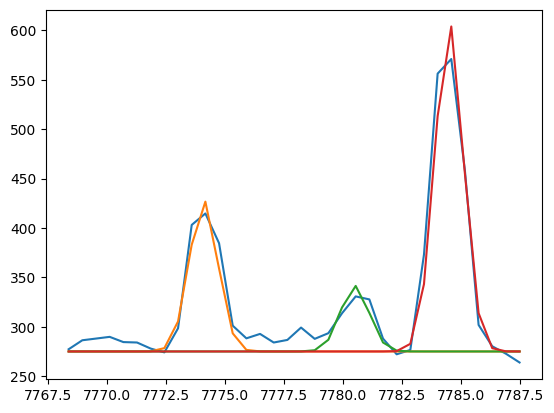

In [55]:
plt.plot(x_arc_7065, y_arc_7065)
plt.plot(x_arc_7065, 275 + gaussian(x_arc_7065, 230, 7774.1, 0, 0.6))
plt.plot(x_arc_7065, 275 + gaussian(x_arc_7065, 100, 7780.5, 0, 0.6))
plt.plot(x_arc_7065, 275 + gaussian(x_arc_7065, 500, 7784.5, 0, 0.6))

In [56]:
params_arc_7065 = Parameters()
params_arc_7065.add('z', value=0.0, vary=False)
params_arc_7065.add('mu1', value=7774.1, vary=False)
params_arc_7065.add('mu2', value=7780.5, vary=False)
params_arc_7065.add('mu3', value=7784.5, vary=False)
params_arc_7065.add('arc1', value=230, min=0.)
params_arc_7065.add('arc2', value=100, min=0.)
params_arc_7065.add('arc3', value=500, min=0.)
params_arc_7065.add('sigma', value=0.6, min=0.)
params_arc_7065.add('bkg', value=275, vary=True)

def residual_arc_7065(params_arc_7065, x, data, uncertainty):
    
    z = params_arc_7065['z']
    mu1 = params_arc_7065['mu1']
    mu2 = params_arc_7065['mu2']
    mu3 = params_arc_7065['mu3']
    flux1 = params_arc_7065['arc1']
    flux2 = params_arc_7065['arc2']
    flux3 = params_arc_7065['arc3']
    sigma = params_arc_7065['sigma']
    bkg = params_arc_7065['bkg']
    
    x = x_arc_7065
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = bkg + model1 + model2 + model3
    return (model - y_arc_7065) / (0.05 * np.max(y_arc_7065))

np.random.seed(950)
out_arc_7065 = minimize(residual_arc_7065, params_arc_7065, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [01:17<00:00, 32.24it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [45.75570011 50.91283089 47.14566297 42.96973637 51.72898296]


In [57]:
out_arc_7065.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,7774.10000,,,7774.1,-inf,inf,False
mu2,7780.50000,,,7780.5,-inf,inf,False
mu3,7784.50000,,,7784.5,-inf,inf,False
arc1,245.103349,39.0073279,(15.91%),230,0.00000000,inf,True
arc2,92.6847791,37.3380575,(40.28%),100,0.00000000,inf,True
arc3,514.781953,44.7469044,(8.69%),500,0.00000000,inf,True
sigma,0.65619320,0.05247193,(8.00%),0.6,0.00000000,inf,True
bkg,279.341102,6.60266950,(2.36%),275,-inf,inf,True


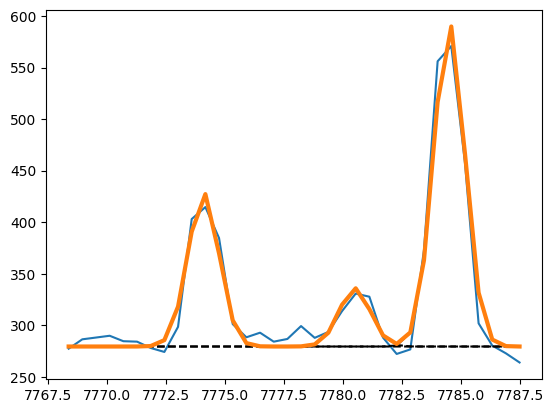

In [58]:
arc1_7065 = out_arc_7065.flatchain.arc1.mean()
arc2_7065 = out_arc_7065.flatchain.arc2.mean()
arc3_7065 = out_arc_7065.flatchain.arc3.mean()
sigma_arc_7065 = out_arc_7065.flatchain.sigma.mean()
bkg_arc_7065 = out_arc_7065.flatchain.bkg.mean()

plt.plot(x_arc_7065, y_arc_7065)

plt.plot(x_arc_7065, bkg_arc_7065 + gaussian(x_arc_7065, arc1_7065, 7774.1, 0, sigma_arc_7065), ls='--', color='black')
plt.plot(x_arc_7065, bkg_arc_7065 + gaussian(x_arc_7065, arc2_7065, 7780.5, 0, sigma_arc_7065), ls='--', color='black')
plt.plot(x_arc_7065, bkg_arc_7065 + gaussian(x_arc_7065, arc3_7065, 7784.5, 0, sigma_arc_7065), ls='--', color='black')

plt.plot(x_arc_7065, bkg_arc_7065 + gaussian(x_arc_7065, arc1_7065, 7774.1, 0, sigma_arc_7065) \
                                  + gaussian(x_arc_7065, arc2_7065, 7780.5, 0, sigma_arc_7065) \
                                  + gaussian(x_arc_7065, arc3_7065, 7784.5, 0, sigma_arc_7065), lw=3)

# HeI 6678

### Arc lines

In [67]:
wave_cat['HeI6678']*(1 + z_BN[igal])

7332.843533285

In [68]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_6678 = [wave_cat['HeI6678']*(1 + z_BN[igal]) - 10, wave_cat['HeI6678']*(1 + z_BN[igal]) + 5]
mask_arc_6678 = (wcal_red[17].data['wave_soln'][0] >= wlims_6678[0]) & (wcal_red[17].data['wave_soln'][0] < wlims_6678[1])

# Arc spectra around the fitted line
x_arc_6678 = wcal_red[17].data['wave_soln'][0][mask_arc_6678]
y_arc_6678 = wcal_red[17].data['spec'][0][mask_arc_6678]

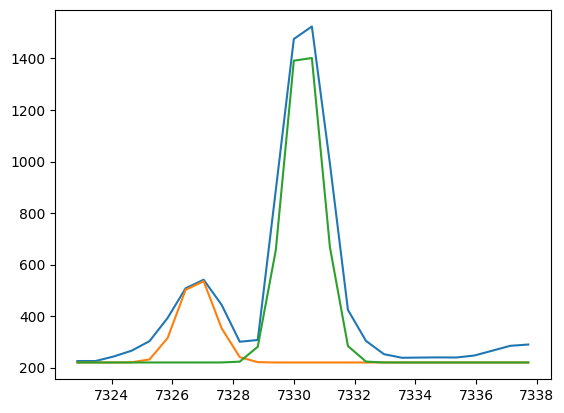

In [69]:
plt.plot(x_arc_6678, y_arc_6678)
plt.plot(x_arc_6678, 220 + gaussian(x_arc_6678,  510, 7326.8, 0, 0.6))
plt.plot(x_arc_6678, 220 + gaussian(x_arc_6678, 2000, 7330.3, 0, 0.6))

In [70]:
params_arc_6678 = Parameters()
params_arc_6678.add('z', value=0.0, vary=False)
params_arc_6678.add('mu1', value=7326.8, vary=True)
params_arc_6678.add('mu2', value=7330.3, vary=True)
params_arc_6678.add('arc1', value=510, min=0.)
params_arc_6678.add('arc2', value=2000, min=0.)
params_arc_6678.add('sigma', value=0.6, min=0.)
params_arc_6678.add('bkg', value=220, vary=True)

def residual_arc_6678(params_arc_6678, x, data, uncertainty):
    
    z = params_arc_6678['z']
    mu1 = params_arc_6678['mu1']
    mu2 = params_arc_6678['mu2']
    flux1 = params_arc_6678['arc1']
    flux2 = params_arc_6678['arc2']
    sigma = params_arc_6678['sigma']
    bkg = params_arc_6678['bkg']
    
    x = x_arc_6678
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model = bkg + model1 + model2
    return (model - y_arc_6678) / (0.05 * np.max(y_arc_6678))

np.random.seed(950)
out_arc_6678 = minimize(residual_arc_6678, params_arc_6678, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [01:09<00:00, 35.79it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [55.62073294 57.80799527 66.75875084 83.49148452 81.37443484 65.22067634]


In [71]:
out_arc_6678.params['arc1'].value

566.6459546680144

In [72]:
out_arc_6678.flatchain.mu1

0       7.326679e+03
1       7.326813e+03
2       7.326869e+03
3       7.326487e+03
4       7.326447e+03
            ...     
9995    7.326721e+03
9996    7.326984e+03
9997    7.326686e+03
9998   -1.346433e+06
9999    7.326776e+03
Name: mu1, Length: 10000, dtype: float64

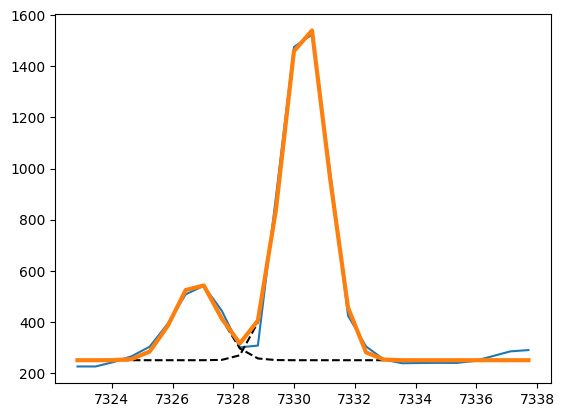

In [73]:
arc1_6678 = out_arc_6678.params['arc1'].value
arc2_6678 = out_arc_6678.flatchain.arc2.mean()

mu1_6678 = out_arc_6678.params['mu1'].value
mu2_6678 = out_arc_6678.flatchain.mu2.mean()

sigma_arc_6678 = out_arc_6678.flatchain.sigma.mean()
bkg_arc_6678 = out_arc_6678.flatchain.bkg.mean()

plt.plot(x_arc_6678, y_arc_6678)

plt.plot(x_arc_6678, bkg_arc_6678 + gaussian(x_arc_6678, arc1_6678, mu1_6678, 0, sigma_arc_6678), ls='--', color='black')
plt.plot(x_arc_6678, bkg_arc_6678 + gaussian(x_arc_6678, arc2_6678, mu2_6678, 0, sigma_arc_6678), ls='--', color='black')

plt.plot(x_arc_6678, bkg_arc_6678 + gaussian(x_arc_6678, arc1_6678, mu1_6678, 0, sigma_arc_6678) \
                                  + gaussian(x_arc_6678, arc2_6678, mu2_6678, 0, sigma_arc_6678), lw=3
)

# HeI 5875

### Arc lines

In [82]:
wave_cat['HeI5875']*(1 + z_BN[igal])

6451.637504735

In [83]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_5875 = [wave_cat['HeI5875']*(1 + z_BN[igal]), wave_cat['HeI5875']*(1 + z_BN[igal]) + 10]
mask_arc_5875 = (wcal_red[15].data['wave_soln'][0] >= wlims_5875[0]) & (wcal_red[15].data['wave_soln'][0] < wlims_5875[1])

# Arc spectra around the fitted line
x_arc_5875 = wcal_red[15].data['wave_soln'][0][mask_arc_5875]
y_arc_5875 = wcal_red[15].data['spec'][0][mask_arc_5875]

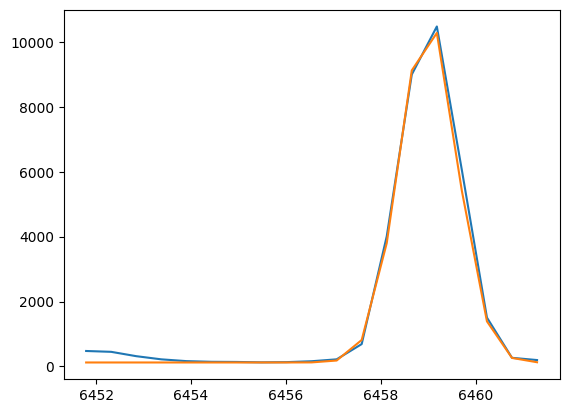

In [84]:
plt.plot(x_arc_5875, y_arc_5875)
plt.plot(x_arc_5875, 120 + gaussian(x_arc_5875, 16000, 6459, 0, 0.6))
#plt.plot(x_arc_5875, 240 + gaussian(x_arc_5875, 2600, 6464.4, 0, 0.5))

In [85]:
params_arc_5875 = Parameters()
params_arc_5875.add('z', value=0.0, vary=False)
params_arc_5875.add('mu1', value=6459, vary=False)
params_arc_5875.add('arc1', value=16000, min=0.)
params_arc_5875.add('sigma', value=0.6, min=0.)
params_arc_5875.add('bkg', value=120, vary=False)

def residual_arc_5875(params_arc_5875, x, data, uncertainty):
    
    z = params_arc_5875['z']
    mu1 = params_arc_5875['mu1']
    flux1 = params_arc_5875['arc1']
    sigma = params_arc_5875['sigma']
    bkg = params_arc_5875['bkg']
    
    x = x_arc_5875
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model = bkg + model1
    return (model - y_arc_5875) / (0.05 * np.max(y_arc_5875))


np.random.seed(950)
out_arc_5875 = minimize(residual_arc_5875, params_arc_5875, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [00:55<00:00, 45.05it/s]


In [86]:
out_arc_5875.params['arc1'].value

16640.903679780065

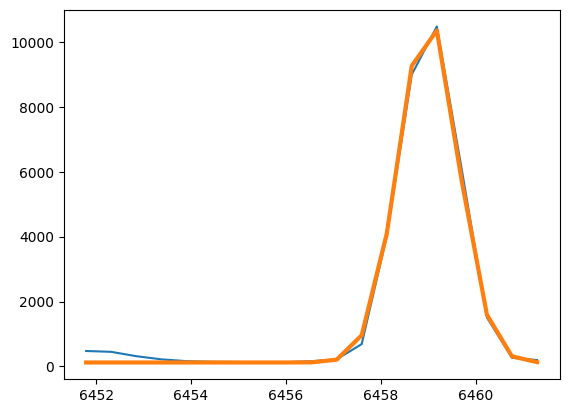

In [87]:
arc1_5875 = out_arc_5875.params['arc1'].value
mu1_5875 = out_arc_5875.params['mu1'].value
sigma_arc_5875 = out_arc_5875.flatchain.sigma.mean()
bkg_arc_5875 = out_arc_5875.params['bkg'].value

plt.plot(x_arc_5875, y_arc_5875)

plt.plot(x_arc_5875, bkg_arc_5875 + gaussian(x_arc_5875, arc1_5875, mu1_5875, 0, sigma_arc_5875), ls='--', color='black')

plt.plot(x_arc_5875, bkg_arc_5875 + gaussian(x_arc_5875, arc1_5875, mu1_5875, 0, sigma_arc_5875), lw=3)

# HeI 4471

### Arc lines

In [96]:
wave_cat['HeI4471']*(1 + z_BN[igal])

4909.841761407

In [97]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_4471 = [wave_cat['HeI4471']*(1 + z_BN[igal]) - 10, wave_cat['HeI4471']*(1 + z_BN[igal])]
mask_arc_4471 = (wcal_red[9].data['wave_soln'][0] >= wlims_4471[0]) & (wcal_red[9].data['wave_soln'][0] < wlims_4471[1])

# Arc spectra around the fitted line
x_arc_4471 = wcal_red[9].data['wave_soln'][0][mask_arc_4471]
y_arc_4471 = wcal_red[9].data['spec'][0][mask_arc_4471]

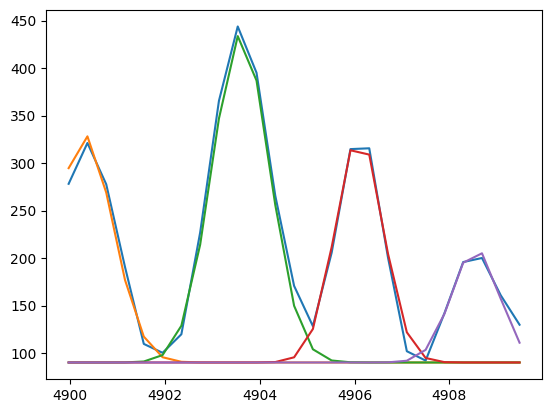

In [98]:
plt.plot(x_arc_4471, y_arc_4471)
plt.plot(x_arc_4471, 90 + gaussian(x_arc_4471, 360, 4900.3, 0, 0.6))
plt.plot(x_arc_4471, 90 + gaussian(x_arc_4471, 520, 4903.6, 0, 0.6))
plt.plot(x_arc_4471, 90 + gaussian(x_arc_4471, 300, 4906.1, 0, 0.5))
plt.plot(x_arc_4471, 90 + gaussian(x_arc_4471, 150, 4908.55, 0, 0.5))

100%|███████████████████████████████████████| 2500/2500 [01:33<00:00, 26.84it/s]


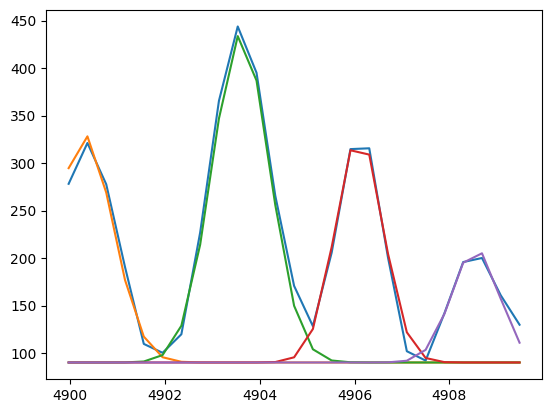

In [99]:
plt.plot(x_arc_4471, y_arc_4471)
plt.plot(x_arc_4471, 90 + gaussian(x_arc_4471, 360, 4900.3, 0, 0.6))
plt.plot(x_arc_4471, 90 + gaussian(x_arc_4471, 520, 4903.6, 0, 0.6))
plt.plot(x_arc_4471, 90 + gaussian(x_arc_4471, 300, 4906.1, 0, 0.5))
plt.plot(x_arc_4471, 90 + gaussian(x_arc_4471, 150, 4908.55, 0, 0.5))

params_arc_4471 = Parameters()
params_arc_4471.add('z', value=0.0, vary=False)
params_arc_4471.add('mu1', value=4900.3, vary=False)
params_arc_4471.add('mu2', value=4903.6, vary=False)
params_arc_4471.add('mu3', value=4906.1, vary=False)
params_arc_4471.add('mu4', value=4908.55, vary=False)
params_arc_4471.add('arc1', value=360, min=0.)
params_arc_4471.add('arc2', value=520, min=0.)
params_arc_4471.add('arc3', value=300, min=0.)
params_arc_4471.add('arc4', value=150, min=0.)
params_arc_4471.add('sigma', value=0.55, min=0.)
params_arc_4471.add('bkg', value=90, vary=False)

def residual_arc_4471(params_arc_4471, x, data, uncertainty):
    
    z = params_arc_4471['z']
    mu1 = params_arc_4471['mu1']
    mu2 = params_arc_4471['mu2']
    mu3 = params_arc_4471['mu3']
    mu4 = params_arc_4471['mu4']
    flux1 = params_arc_4471['arc1']
    flux2 = params_arc_4471['arc2']
    flux3 = params_arc_4471['arc3']
    flux4 = params_arc_4471['arc4']
    sigma = params_arc_4471['sigma']
    bkg = params_arc_4471['bkg']
    
    x = x_arc_4471
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model = bkg + model1 + model2 + model3 + model4
    return (model - y_arc_4471) / (0.05 * np.max(y_arc_4471))

np.random.seed(950)
out_arc_4471 = minimize(residual_arc_4471, params_arc_4471, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

In [100]:
out_arc_4471.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,4900.30000,,,4900.3,-inf,inf,False
mu2,4903.60000,,,4903.6,-inf,inf,False
mu3,4906.10000,,,4906.1,-inf,inf,False
mu4,4908.55000,,,4908.55,-inf,inf,False
arc1,340.816725,22.1857760,(6.51%),360,0.00000000,inf,True
arc2,526.416027,21.9416764,(4.17%),520,0.00000000,inf,True
arc3,314.874360,19.8256991,(6.30%),300,0.00000000,inf,True
arc4,158.075650,19.7818533,(12.51%),150,0.00000000,inf,True
sigma,0.56827881,0.02095637,(3.69%),0.55,0.00000000,inf,True


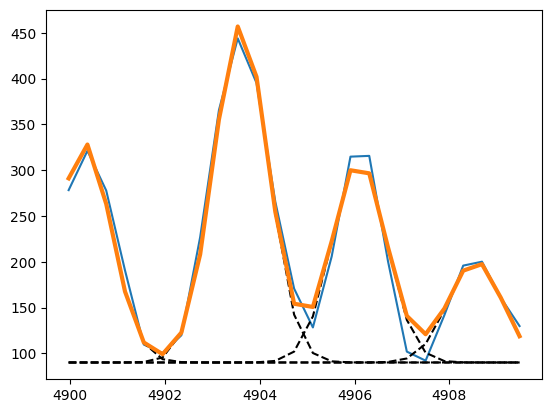

In [101]:
arc1_4471 = out_arc_4471.flatchain.arc1.mean()
arc2_4471 = out_arc_4471.flatchain.arc2.mean()
arc3_4471 = out_arc_4471.flatchain.arc3.mean()
arc4_4471 = out_arc_4471.flatchain.arc4.mean()
sigma_arc_4471 = out_arc_4471.flatchain.sigma.mean()

plt.plot(x_arc_4471, y_arc_4471)

plt.plot(x_arc_4471, 90 + gaussian(x_arc_4471, arc1_4471,  4900.3, 0, sigma_arc_4471), ls='--', color='black')
plt.plot(x_arc_4471, 90 + gaussian(x_arc_4471, arc2_4471,  4903.6, 0, sigma_arc_4471), ls='--', color='black')
plt.plot(x_arc_4471, 90 + gaussian(x_arc_4471, arc3_4471,  4906.1, 0, sigma_arc_4471), ls='--', color='black')
plt.plot(x_arc_4471, 90 + gaussian(x_arc_4471, arc4_4471, 4908.55, 0, sigma_arc_4471), ls='--', color='black')

plt.plot(x_arc_4471, 90 + gaussian(x_arc_4471, arc1_4471,  4900.3, 0, sigma_arc_4471) \
                        + gaussian(x_arc_4471, arc2_4471,  4903.6, 0, sigma_arc_4471) \
                        + gaussian(x_arc_4471, arc3_4471,  4906.1, 0, sigma_arc_4471) \
                        + gaussian(x_arc_4471, arc4_4471, 4908.55, 0, sigma_arc_4471), lw=3
)

# [SII]6716 + [SII]6730

### Arc lines

In [110]:
wave_cat['[SII]6730']*(1 + z_BN[igal])

7390.670448525

In [111]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_6730 = [wave_cat['[SII]6730']*(1 + z_BN[igal]), wave_cat['[SII]6730']*(1 + z_BN[igal]) + 10]
mask_arc_6730 = (wcal_red[17].data['wave_soln'][0] >= wlims_6730[0]) & (wcal_red[17].data['wave_soln'][0] < wlims_6730[1])

# Arc spectra around the fitted line
x_arc_6730 = wcal_red[17].data['wave_soln'][0][mask_arc_6730]
y_arc_6730 = wcal_red[17].data['spec'][0][mask_arc_6730]

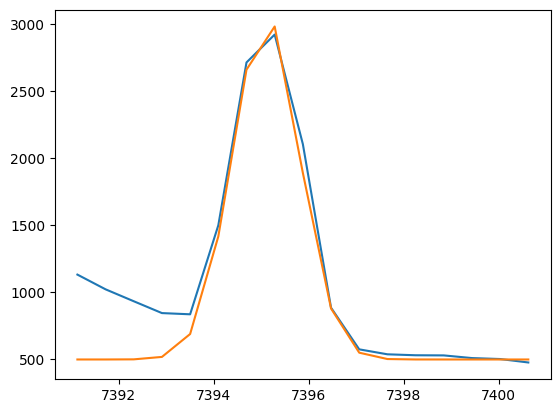

In [112]:
plt.plot(x_arc_6730, y_arc_6730)
plt.plot(x_arc_6730, 500 + gaussian(x_arc_6730, 4500, 7395.1, 0, 0.7))

In [113]:
params_arc_6730 = Parameters()
params_arc_6730.add('z', value=0.0, vary=False)
params_arc_6730.add('mu', value=7395.1, vary=False)
params_arc_6730.add('arc', value=4500, min=0.)
params_arc_6730.add('sigma', value=0.7, min=0.)
params_arc_6730.add('bkg', value=500, vary=False)

def residual_arc_6730(params_arc_6730, x, data, uncertainty):
    
    z = params_arc_6730['z']
    mu = params_arc_6730['mu']
    flux = params_arc_6730['arc']
    sigma = params_arc_6730['sigma']
    bkg = params_arc_6730['bkg']
    
    x = x_arc_6730
    model = bkg + gaussian(x, flux, mu, z, sigma)
    return (model - y_arc_6730) / 10

np.random.seed(950)
out_arc_6730 = minimize(residual_arc_6730, params_arc_6730, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [00:46<00:00, 53.57it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [54.34957467 51.94094196]


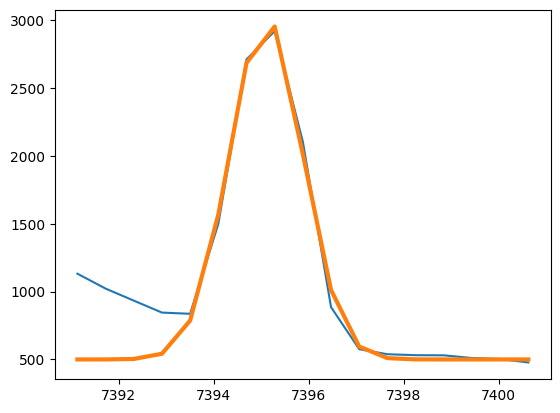

In [114]:
arc_6730 = out_arc_6730.flatchain.arc.mean()
sigma_arc_6730 = out_arc_6730.flatchain.sigma.mean()

plt.plot(x_arc_6730, y_arc_6730)

plt.plot(x_arc_6730, 500 + gaussian(x_arc_6730, arc_6730, 7395.1, 0, sigma_arc_6730), lw=3)

# [NII]5755

### Arc lines

In [123]:
wave_cat['[NII]5755']*(1 + z_BN[igal])

6318.741230650001

In [124]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_5755 = [wave_cat['[NII]5755']*(1 + z_BN[igal]) + 3, wave_cat['[NII]5755']*(1 + z_BN[igal]) + 13]
mask_arc_5755 = (wcal_red[13].data['wave_soln'][0] >= wlims_5755[0]) & (wcal_red[13].data['wave_soln'][0] < wlims_5755[1])

# Arc spectra around the fitted line
x_arc_5755 = wcal_red[13].data['wave_soln'][0][mask_arc_5755]
y_arc_5755 = wcal_red[13].data['spec'][0][mask_arc_5755]

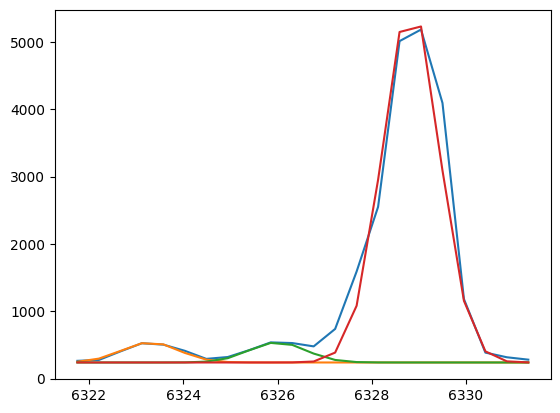

In [125]:
plt.plot(x_arc_5755, y_arc_5755)
plt.plot(x_arc_5755, 240 + gaussian(x_arc_5755, 450, 6323.3, 0, 0.6))
plt.plot(x_arc_5755, 240 + gaussian(x_arc_5755, 450, 6326, 0, 0.6))
plt.plot(x_arc_5755, 240 + gaussian(x_arc_5755, 8000, 6328.83, 0, 0.6))

In [126]:
params_arc_5755 = Parameters()
params_arc_5755.add('z', value=0.0, vary=False)
params_arc_5755.add('mu1', value=6323.3, vary=False)
params_arc_5755.add('mu2', value=6326, vary=False)
params_arc_5755.add('mu3', value=6328.83, vary=False)
params_arc_5755.add('arc1', value=450, min=0.)
params_arc_5755.add('arc2', value=450, min=0.)
params_arc_5755.add('arc3', value=8000, min=0.)
params_arc_5755.add('sigma', value=0.6, min=0.)
params_arc_5755.add('bkg', value=240, vary=False)

def residual_arc_5755(params_arc_5755, x, data, uncertainty):
    
    z = params_arc_5755['z']
    mu1 = params_arc_5755['mu1']
    mu2 = params_arc_5755['mu2']
    mu3 = params_arc_5755['mu3']
    flux1 = params_arc_5755['arc1']
    flux2 = params_arc_5755['arc2']
    flux3 = params_arc_5755['arc3']
    sigma = params_arc_5755['sigma']
    bkg = params_arc_5755['bkg']
    
    x = x_arc_5755
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = bkg + model1 + model2 + model3
    return (model - y_arc_5755) / 10

np.random.seed(950)
out_arc_5755 = minimize(residual_arc_5755, params_arc_5755, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [01:01<00:00, 40.50it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [44.13321188 65.72080203 65.37432384 60.93647782]


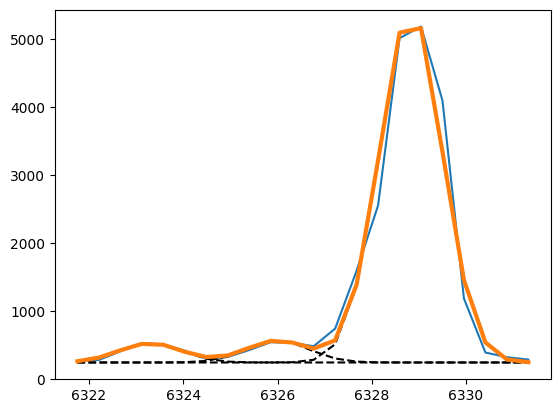

In [127]:
arc1_5755 = out_arc_5755.flatchain.arc1.mean()
arc2_5755 = out_arc_5755.flatchain.arc2.mean()
arc3_5755 = out_arc_5755.flatchain.arc3.mean()
sigma_arc_5755 = out_arc_5755.flatchain.sigma.mean()

plt.plot(x_arc_5755, y_arc_5755)

plt.plot(x_arc_5755, 240 + gaussian(x_arc_5755, arc1_5755, 6323.3, 0, sigma_arc_5755), ls='--', color='black')
plt.plot(x_arc_5755, 240 + gaussian(x_arc_5755, arc2_5755, 6326, 0, sigma_arc_5755), ls='--', color='black')
plt.plot(x_arc_5755, 240 + gaussian(x_arc_5755, arc3_5755, 6328.83, 0, sigma_arc_5755), ls='--', color='black')

plt.plot(x_arc_5755, 240 + gaussian(x_arc_5755, arc1_5755, 6323.3, 0, sigma_arc_5755) \
         + gaussian(x_arc_5755, arc2_5755, 6326, 0, sigma_arc_5755) \
         + gaussian(x_arc_5755, arc3_5755, 6328.83, 0, sigma_arc_5755), lw=3
)

# H$\beta$

### Arc lines

In [136]:
wave_cat['Hb']*(1 + z_BN[igal])

5337.932447250001

In [137]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_hb = [wave_cat['Hb']*(1 + z_BN[igal]) - 10, wave_cat['Hb']*(1 + z_BN[igal]) + 10]
mask_arc_hb = (wcal_red[11].data['wave_soln'][0] >= wlims_hb[0]) & (wcal_red[11].data['wave_soln'][0] < wlims_hb[1])

# Arc spectra around the fitted line
x_arc_hb = wcal_red[11].data['wave_soln'][0][mask_arc_hb]
y_arc_hb = wcal_red[11].data['spec'][0][mask_arc_hb]

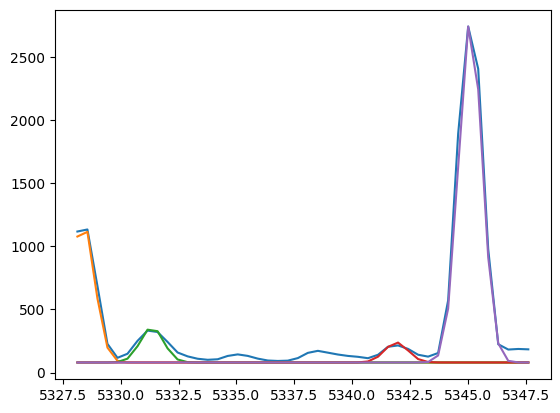

In [138]:
plt.plot(x_arc_hb, y_arc_hb)
plt.plot(x_arc_hb, 80 + gaussian(x_arc_hb, 1400, 5328.37, 0, 0.5))
plt.plot(x_arc_hb, 80 + gaussian(x_arc_hb, 350, 5331.35, 0, 0.5))
plt.plot(x_arc_hb, 80 + gaussian(x_arc_hb, 200, 5341.9, 0, 0.5))
plt.plot(x_arc_hb, 80 + gaussian(x_arc_hb, 3400, 5345.1, 0, 0.5))

In [139]:
params_arc_hb = Parameters()
params_arc_hb.add('z', value=0.0, vary=False)
params_arc_hb.add('mu1', value=5328.37, vary=False)
params_arc_hb.add('mu2', value=5331.35, vary=False)
params_arc_hb.add('mu3', value=5341.9, vary=False)
params_arc_hb.add('mu4', value=5345.1, vary=False)
params_arc_hb.add('arc1', value=1400, min=0.)
params_arc_hb.add('arc2', value=350, min=0.)
params_arc_hb.add('arc3', value=200, min=0.)
params_arc_hb.add('arc4', value=3400, min=0.)
params_arc_hb.add('sigma', value=0.5, min=0.)
params_arc_hb.add('bkg', value=80, vary=False)

def residual_arc_hb(params_arc_hb, x, data, uncertainty):
    
    z = params_arc_hb['z']
    mu1 = params_arc_hb['mu1']
    mu2 = params_arc_hb['mu2']
    mu3 = params_arc_hb['mu3']
    mu4 = params_arc_hb['mu4']
    flux1 = params_arc_hb['arc1']
    flux2 = params_arc_hb['arc2']
    flux3 = params_arc_hb['arc3']
    flux4 = params_arc_hb['arc4']
    sigma = params_arc_hb['sigma']
    bkg = params_arc_hb['bkg']
    
    x = x_arc_hb
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model = bkg + model1 + model2 + model3 + model4
    return (model - y_arc_hb) / 10

np.random.seed(950)
out_arc_hb = minimize(residual_arc_hb, params_arc_hb, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [01:11<00:00, 35.11it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [55.39082448 44.17066375 49.67285203 60.07096257 62.77346279]


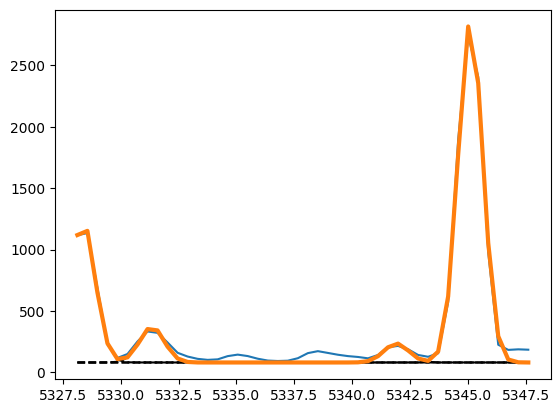

In [140]:
arc1_hb = out_arc_hb.flatchain.arc1.mean()
arc2_hb = out_arc_hb.flatchain.arc2.mean()
arc3_hb = out_arc_hb.flatchain.arc3.mean()
arc4_hb = out_arc_hb.flatchain.arc4.mean()
sigma_arc_hb = out_arc_hb.flatchain.sigma.mean()

plt.plot(x_arc_hb, y_arc_hb)

plt.plot(x_arc_hb, 80 + gaussian(x_arc_hb, arc1_hb, 5328.37, 0, sigma_arc_hb), ls='--', color='black')
plt.plot(x_arc_hb, 80 + gaussian(x_arc_hb, arc2_hb, 5331.35, 0, sigma_arc_hb), ls='--', color='black')
plt.plot(x_arc_hb, 80 + gaussian(x_arc_hb, arc3_hb, 5341.9, 0, sigma_arc_hb), ls='--', color='black')
plt.plot(x_arc_hb, 80 + gaussian(x_arc_hb, arc4_hb, 5345.1, 0, sigma_arc_hb), ls='--', color='black')

plt.plot(x_arc_hb, 80 + gaussian(x_arc_hb, arc1_hb, 5328.37, 0, sigma_arc_hb) \
         + gaussian(x_arc_hb, arc2_hb, 5331.35, 0, sigma_arc_hb) \
         + gaussian(x_arc_hb, arc3_hb, 5341.9, 0, sigma_arc_hb) \
         + gaussian(x_arc_hb, arc4_hb, 5345.1, 0, sigma_arc_hb), lw=3
)

# H$\gamma$

### Arc lines

In [149]:
wave_cat['Hg']*(1 + z_BN[igal]) 

4765.99017252

In [150]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_hg = [wave_cat['Hg']*(1 + z_BN[igal]) - 10, wave_cat['Hg']*(1 + z_BN[igal]) + 10]
mask_arc_hg = (wcal_red[7].data['wave_soln'][0] >= wlims_hg[0]) & (wcal_red[7].data['wave_soln'][0] < wlims_hg[1])

# Arc spectra around the fitted line
x_arc_hg = wcal_red[7].data['wave_soln'][0][mask_arc_hg]
y_arc_hg = wcal_red[7].data['spec'][0][mask_arc_hg]

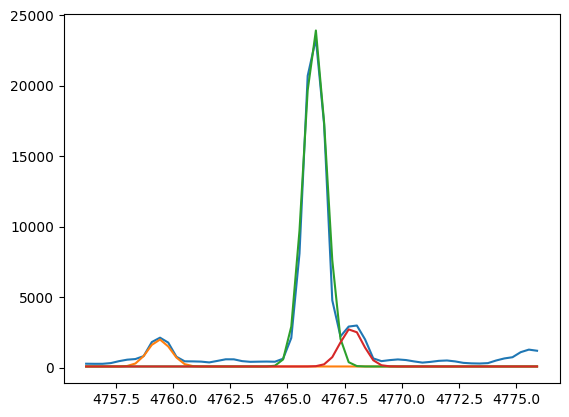

In [151]:
plt.plot(x_arc_hg, y_arc_hg)
plt.plot(x_arc_hg, 80 + gaussian(x_arc_hg,  2400, 4759.4, 0, 0.5))
plt.plot(x_arc_hg, 80 + gaussian(x_arc_hg, 30000, 4766.2, 0, 0.5))
plt.plot(x_arc_hg, 80 + gaussian(x_arc_hg,  3400, 4767.8, 0, 0.5))

In [152]:
params_arc_hg = Parameters()
params_arc_hg.add('z', value=0.0, vary=False)
params_arc_hg.add('mu1', value=4759.4, vary=False)
params_arc_hg.add('mu2', value=4766.2, vary=False)
params_arc_hg.add('mu3', value=4767.8, vary=False)
params_arc_hg.add('arc1', value= 2400, min=0.)
params_arc_hg.add('arc2', value=30000, min=0.)
params_arc_hg.add('arc3', value= 3400, min=0.)
params_arc_hg.add('sigma', value=0.5, min=0.)
params_arc_hg.add('bkg', value=80, vary=True)

def residual_arc_hg(params_arc_hg, x, data, uncertainty):
    
    z = params_arc_hg['z']
    mu1 = params_arc_hg['mu1']
    mu2 = params_arc_hg['mu2']
    mu3 = params_arc_hg['mu3']
    flux1 = params_arc_hg['arc1']
    flux2 = params_arc_hg['arc2']
    flux3 = params_arc_hg['arc3']
    sigma = params_arc_hg['sigma']
    bkg = params_arc_hg['bkg']
    
    x = x_arc_hg
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = bkg + model1 + model2 + model3
    return (model - y_arc_hg) / 10

np.random.seed(950)
out_arc_hg = minimize(residual_arc_hg, params_arc_hg, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [00:56<00:00, 44.04it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [124.6378372   99.41598625 126.28073607  72.30862996 124.30669476]


In [153]:
out_arc_hg.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,4759.40000,,,4759.4,-inf,inf,False
mu2,4766.20000,,,4766.2,-inf,inf,False
mu3,4767.80000,,,4767.8,-inf,inf,False
arc1,1849.35604,7.70639222,(0.42%),2400,0.00000000,inf,True
arc2,26650.6753,9.17345403,(0.03%),30000,0.00000000,inf,True
arc3,2684.09124,7.85326801,(0.29%),3400,0.00000000,inf,True
sigma,0.43714261,1.6409e-04,(0.04%),0.5,0.00000000,inf,True
bkg,494.612094,1.53391962,(0.31%),80,-inf,inf,True


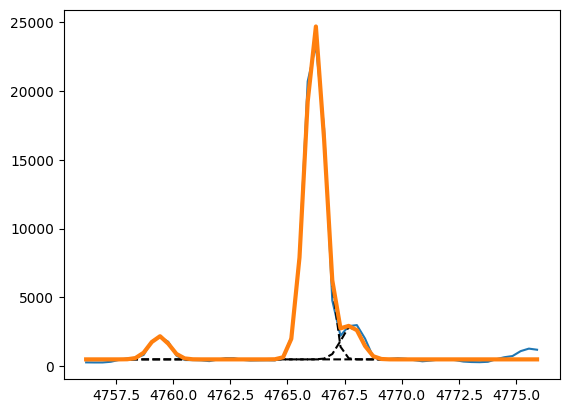

In [154]:
arc1_hg = out_arc_hg.flatchain.arc1.mean()
arc2_hg = out_arc_hg.flatchain.arc2.mean()
arc3_hg = out_arc_hg.flatchain.arc3.mean()
sigma_arc_hg = out_arc_hg.flatchain.sigma.mean()
bkg_arc_hg = out_arc_hg.flatchain.bkg.mean()

plt.plot(x_arc_hg, y_arc_hg)

plt.plot(x_arc_hg, bkg_arc_hg + gaussian(x_arc_hg, arc1_hg, 4759.4, 0, sigma_arc_hg), ls='--', color='black')
plt.plot(x_arc_hg, bkg_arc_hg + gaussian(x_arc_hg, arc2_hg, 4766.2, 0, sigma_arc_hg), ls='--', color='black')
plt.plot(x_arc_hg, bkg_arc_hg + gaussian(x_arc_hg, arc3_hg, 4767.8, 0, sigma_arc_hg), ls='--', color='black')

plt.plot(x_arc_hg, bkg_arc_hg + gaussian(x_arc_hg, arc1_hg, 4759.4, 0, sigma_arc_hg) \
                              + gaussian(x_arc_hg, arc2_hg, 4766.2, 0, sigma_arc_hg) \
                              + gaussian(x_arc_hg, arc3_hg, 4767.8, 0, sigma_arc_hg), lw=3
)

# H$\delta$

### Arc lines

In [163]:
wave_cat['Hg']*(1 + z_BN[igal]) 

4765.99017252

In [164]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_hd = [wave_cat['Hd']*(1 + z_BN[igal]) - 13, wave_cat['Hd']*(1 + z_BN[igal]) + 10]
mask_arc_hd = (wcal_red[7].data['wave_soln'][0] >= wlims_hd[0]) & (wcal_red[7].data['wave_soln'][0] < wlims_hd[1])

# Arc spectra around the fitted line
x_arc_hd = wcal_red[7].data['wave_soln'][0][mask_arc_hd]
y_arc_hd = wcal_red[7].data['spec'][0][mask_arc_hd]

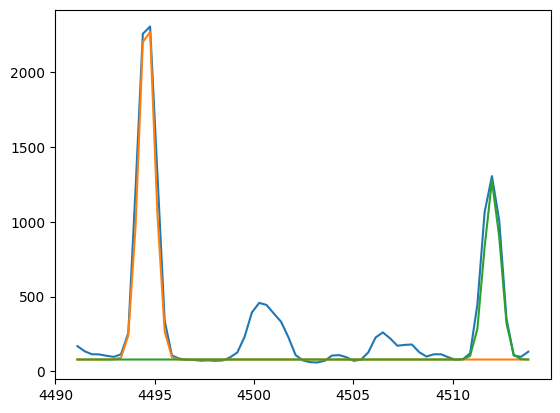

In [165]:
plt.plot(x_arc_hd, y_arc_hd)
plt.plot(x_arc_hd, 80 + gaussian(x_arc_hd,  2400, 4494.6, 0, 0.4))
plt.plot(x_arc_hd, 80 + gaussian(x_arc_hd,  1200,   4512, 0, 0.4))

In [166]:
params_arc_hd = Parameters()
params_arc_hd.add('z', value=0.0, vary=False)
params_arc_hd.add('mu1', value=4494.6, vary=False)
params_arc_hd.add('mu2', value=  4512, vary=False)
params_arc_hd.add('arc1', value=2400, min=0.)
params_arc_hd.add('arc2', value=1200, min=0.)
params_arc_hd.add('sigma', value=0.4, min=0.)
params_arc_hd.add('bkg', value=80, vary=False)

def residual_arc_hd(params_arc_hd, x, data, uncertainty):
    
    z = params_arc_hd['z']
    mu1 = params_arc_hd['mu1']
    mu2 = params_arc_hd['mu2']
    flux1 = params_arc_hd['arc1']
    flux2 = params_arc_hd['arc2']
    sigma = params_arc_hd['sigma']
    bkg = params_arc_hd['bkg']
    
    x = x_arc_hd
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model = bkg + model1 + model2
    return (model - y_arc_hd) / 10

np.random.seed(950)
out_arc_hd = minimize(residual_arc_hd, params_arc_hd, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [00:40<00:00, 62.05it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [69.93521507 79.79615921 72.41927746]


In [167]:
out_arc_hd.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,4494.60000,,,4494.6,-inf,inf,False
mu2,4512.00000,,,4512,-inf,inf,False
arc1,2705.92883,8.93436185,(0.33%),2400,0.00000000,inf,True
arc2,1430.29938,7.86528333,(0.55%),1200,0.00000000,inf,True
sigma,0.44685508,0.00157457,(0.35%),0.4,0.00000000,inf,True
bkg,80.0000000,,,80,-inf,inf,False


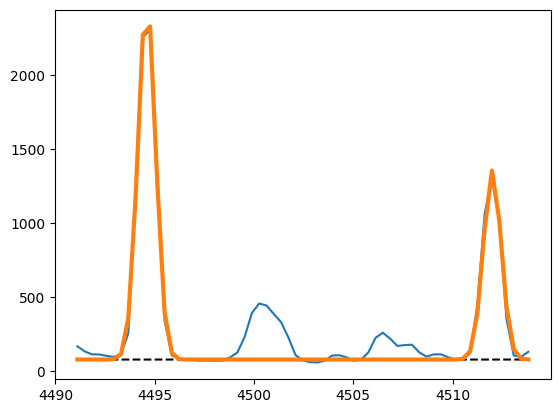

In [168]:
arc1_hd = out_arc_hd.flatchain.arc1.mean()
arc2_hd = out_arc_hd.flatchain.arc2.mean()
sigma_arc_hd = out_arc_hd.flatchain.sigma.mean()

plt.plot(x_arc_hd, y_arc_hd)

plt.plot(x_arc_hd, 80 + gaussian(x_arc_hd, arc1_hd, 4494.6, 0, sigma_arc_hd), ls='--', color='black')
plt.plot(x_arc_hd, 80 + gaussian(x_arc_hd, arc2_hd,   4512, 0, sigma_arc_hd), ls='--', color='black')

plt.plot(x_arc_hd, 80 + gaussian(x_arc_hd, arc1_hd, 4494.6, 0, sigma_arc_hd) \
                      + gaussian(x_arc_hd, arc2_hd,   4512, 0, sigma_arc_hd), lw=3
)

# HeII 4686

### Arc lines

In [177]:
wave_cat['HeII4685']*(1 + z_BN[igal])

5145.073579850001

In [178]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_4685 = [wave_cat['HeII4685']*(1 + z_BN[igal]) - 10, wave_cat['HeII4685']*(1 + z_BN[igal]) - 5]
mask_arc_4685 = (wcal_red[9].data['wave_soln'][0] >= wlims_4685[0]) & (wcal_red[9].data['wave_soln'][0] < wlims_4685[1])

# Arc spectra around the fitted line
x_arc_4685 = wcal_red[9].data['wave_soln'][0][mask_arc_4685]
y_arc_4685 = wcal_red[9].data['spec'][0][mask_arc_4685]

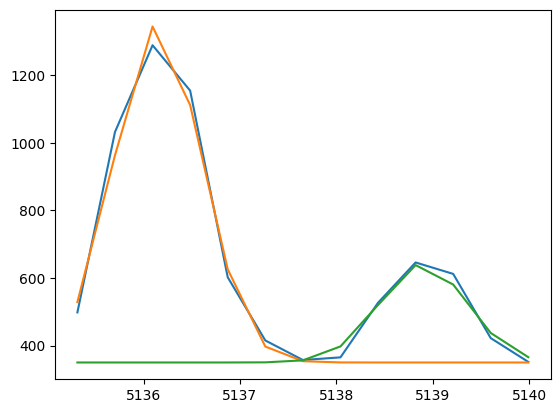

In [179]:
plt.plot(x_arc_4685, y_arc_4685)
plt.plot(x_arc_4685, 350 + gaussian(x_arc_4685, 1130, 5136.15, 0, 0.45))
plt.plot(x_arc_4685, 350 + gaussian(x_arc_4685, 330, 5138.9, 0, 0.45))

In [180]:
params_arc_4685 = Parameters()
params_arc_4685.add('z', value=0.0, vary=False)
params_arc_4685.add('mu1', value=5136.15, vary=False)
params_arc_4685.add('mu2', value= 5138.9, vary=False)
params_arc_4685.add('arc1', value=1130, min=0.)
params_arc_4685.add('arc2', value= 330, min=0.)
params_arc_4685.add('sigma', value=0.45, min=0.)
params_arc_4685.add('bkg', value=350, vary=False)

def residual_arc_4685(params_arc_4685, x, data, uncertainty):
    
    z = params_arc_4685['z']
    mu1 = params_arc_4685['mu1']
    mu2 = params_arc_4685['mu2']
    flux1 = params_arc_4685['arc1']
    flux2 = params_arc_4685['arc2']
    sigma = params_arc_4685['sigma']
    bkg = params_arc_4685['bkg']
    
    x = x_arc_4685
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model = bkg + model1 + model2
    return (model - y_arc_4685) / 10

np.random.seed(950)
out_arc_4685 = minimize(residual_arc_4685, params_arc_4685, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [00:31<00:00, 80.26it/s]


In [181]:
out_arc_4685.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,5136.15000,,,5136.15,-inf,inf,False
mu2,5138.90000,,,5138.9,-inf,inf,False
arc1,1141.56039,9.52993800,(0.83%),1130,0.00000000,inf,True
arc2,345.830819,8.05894442,(2.33%),330,0.00000000,inf,True
sigma,0.45530620,0.00424161,(0.93%),0.45,0.00000000,inf,True
bkg,350.000000,,,350,-inf,inf,False


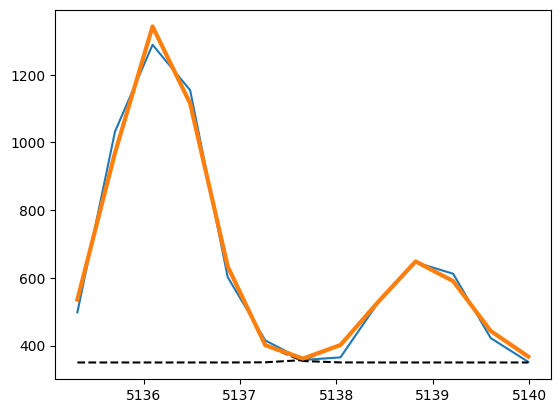

In [182]:
arc1_4685 = out_arc_4685.flatchain.arc1.mean()
arc2_4685 = out_arc_4685.flatchain.arc2.mean()
sigma_arc_4685 = out_arc_4685.flatchain.sigma.mean()

plt.plot(x_arc_4685, y_arc_4685)

plt.plot(x_arc_4685, 350 + gaussian(x_arc_4685, arc1_4685, 5136.15, 0, sigma_arc_4685), ls='--', color='black')
plt.plot(x_arc_4685, 350 + gaussian(x_arc_4685, arc2_4685,  5138.9, 0, sigma_arc_4685), ls='--', color='black')

plt.plot(x_arc_4685, 350 + gaussian(x_arc_4685, arc1_4685, 5136.15, 0, sigma_arc_4685) \
                         + gaussian(x_arc_4685, arc2_4685,  5138.9, 0, sigma_arc_4685), lw=3
)

# [OII]3726 + [OII]3729

In [193]:
wave_cat['[OII]3729']*(1 + z_BN[igal])

4094.3693785250002

### Arc lines

In [194]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_3729 = [wave_cat['[OII]3729']*(1 + z_BN[igal]) - 10, wave_cat['[OII]3729']*(1 + z_BN[igal])]
mask_arc_3729 = (wcal_red[3].data['wave_soln'][0] >= wlims_3729[0]) & (wcal_red[3].data['wave_soln'][0] < wlims_3729[1])

# Arc spectra around the fitted line
x_arc_3729 = wcal_red[3].data['wave_soln'][0][mask_arc_3729]
y_arc_3729 = wcal_red[3].data['spec'][0][mask_arc_3729]

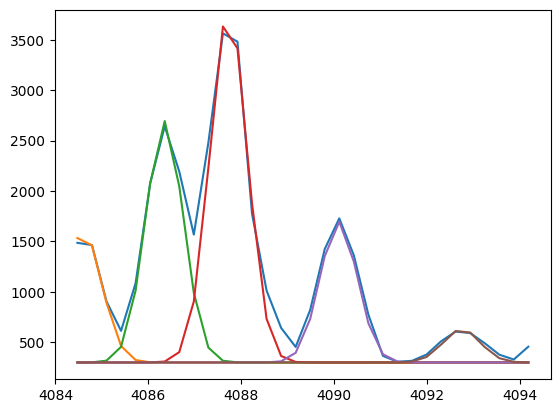

In [195]:
plt.plot(x_arc_3729, y_arc_3729)
plt.plot(x_arc_3729, 300 + gaussian(x_arc_3729, 1300, 4084.6, 0, 0.4))
plt.plot(x_arc_3729, 300 + gaussian(x_arc_3729, 2400, 4086.35, 0, 0.4))
plt.plot(x_arc_3729, 300 + gaussian(x_arc_3729, 3500, 4087.73, 0, 0.4))
plt.plot(x_arc_3729, 300 + gaussian(x_arc_3729, 1400, 4090.1, 0, 0.4))
plt.plot(x_arc_3729, 300 + gaussian(x_arc_3729, 330, 4092.75, 0, 0.4))

In [196]:
params_arc_3729 = Parameters()
params_arc_3729.add('z', value=0.0, vary=False)
params_arc_3729.add('mu1', value=4084.6, vary=False)
params_arc_3729.add('mu2', value=4086.35, vary=False)
params_arc_3729.add('mu3', value=4087.73, vary=False)
params_arc_3729.add('mu4', value=4090.1, vary=False)
params_arc_3729.add('mu5', value=4092.75, vary=False)
params_arc_3729.add('arc1', value=1300, min=0.)
params_arc_3729.add('arc2', value=2400, min=0.)
params_arc_3729.add('arc3', value=3500, min=0.)
params_arc_3729.add('arc4', value=1400, min=0.)
params_arc_3729.add('arc5', value=330, min=0.)
params_arc_3729.add('sigma', value=0.4, min=0.)
params_arc_3729.add('bkg', value=300, vary=False)

def residual_arc_3729(params_arc_3729, x, data, uncertainty):
    
    z = params_arc_3729['z']
    mu1 = params_arc_3729['mu1']
    mu2 = params_arc_3729['mu2']
    mu3 = params_arc_3729['mu3']
    mu4 = params_arc_3729['mu4']
    mu5 = params_arc_3729['mu5']
    flux1 = params_arc_3729['arc1']
    flux2 = params_arc_3729['arc2']
    flux3 = params_arc_3729['arc3']
    flux4 = params_arc_3729['arc4']
    flux5 = params_arc_3729['arc5']
    sigma = params_arc_3729['sigma']
    bkg = params_arc_3729['bkg']
    
    x = x_arc_3729
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5
    return (model - y_arc_3729) / 10

np.random.seed(950)
out_arc_3729 = minimize(residual_arc_3729, params_arc_3729, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [00:38<00:00, 64.31it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [59.85180549 52.78537535 77.00606737 89.54607444 91.75118483 68.46219605]


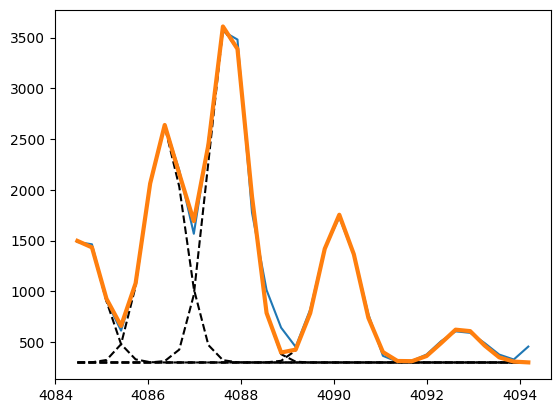

In [197]:
arc1_3729 = out_arc_3729.flatchain.arc1.mean()
arc2_3729 = out_arc_3729.flatchain.arc2.mean()
arc3_3729 = out_arc_3729.flatchain.arc3.mean()
arc4_3729 = out_arc_3729.flatchain.arc4.mean()
arc5_3729 = out_arc_3729.flatchain.arc5.mean()
sigma_arc_3729 = out_arc_3729.flatchain.sigma.mean()

plt.plot(x_arc_3729, y_arc_3729)

plt.plot(x_arc_3729, 300 + gaussian(x_arc_3729, arc1_3729, 4084.6, 0, sigma_arc_3729), ls='--', color='black')
plt.plot(x_arc_3729, 300 + gaussian(x_arc_3729, arc2_3729, 4086.35, 0, sigma_arc_3729), ls='--', color='black')
plt.plot(x_arc_3729, 300 + gaussian(x_arc_3729, arc3_3729, 4087.73, 0, sigma_arc_3729), ls='--', color='black')
plt.plot(x_arc_3729, 300 + gaussian(x_arc_3729, arc4_3729, 4090.1, 0, sigma_arc_3729), ls='--', color='black')
plt.plot(x_arc_3729, 300 + gaussian(x_arc_3729, arc5_3729, 4092.75, 0, sigma_arc_3729), ls='--', color='black')

plt.plot(x_arc_3729, 300 + gaussian(x_arc_3729, arc1_3729, 4084.6, 0, sigma_arc_3729) \
         + gaussian(x_arc_3729, arc2_3729, 4086.35, 0, sigma_arc_3729) \
         + gaussian(x_arc_3729, arc3_3729, 4087.73, 0, sigma_arc_3729) \
         + gaussian(x_arc_3729, arc4_3729, 4090.1, 0, sigma_arc_3729) \
         + gaussian(x_arc_3729, arc5_3729, 4092.75, 0, sigma_arc_3729), lw=3
)

# [SIII]9532

### Arc lines

In [206]:
wave_cat['[SIII]9532']*(1 + z_BN[igal])

10465.481388500002

In [207]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_9532 = [wave_cat['[SIII]9532']*(1 + z_BN[igal]), wave_cat['[SIII]9532']*(1 + z_BN[igal]) + 20]
mask_arc_9532 = (wcal_red[21].data['wave_soln'][0] >= wlims_9532[0]) & (wcal_red[21].data['wave_soln'][0] < wlims_9532[1])

# Arc spectra around the fitted line
x_arc_9532 = wcal_red[21].data['wave_soln'][0][mask_arc_9532]
y_arc_9532 = wcal_red[21].data['spec'][0][mask_arc_9532]

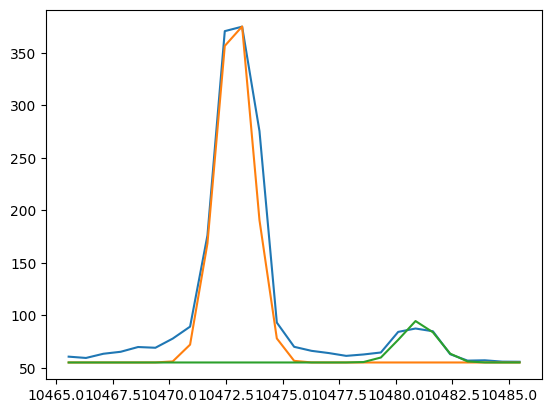

In [208]:
plt.plot(x_arc_9532, y_arc_9532)
plt.plot(x_arc_9532, 55 + gaussian(x_arc_9532, 700, 10472.88, 0, 0.8))
plt.plot(x_arc_9532, 55 + gaussian(x_arc_9532, 80, 10481, 0, 0.8))

In [209]:
params_arc_9532 = Parameters()
params_arc_9532.add('z', value=0.0, vary=False)
params_arc_9532.add('mu1', value=10472.88, vary=False)
params_arc_9532.add('mu2', value=10481, vary=False)
params_arc_9532.add('arc1', value=700, min=0.)
params_arc_9532.add('arc2', value=80, min=0.)
params_arc_9532.add('sigma', value=0.8, min=0.)
params_arc_9532.add('bkg', value=55, vary=False)

def residual_arc_9532(params_arc_9532, x, data, uncertainty):
    
    z = params_arc_9532['z']
    mu1 = params_arc_9532['mu1']
    mu2 = params_arc_9532['mu2']
    flux1 = params_arc_9532['arc1']
    flux2 = params_arc_9532['arc2']
    sigma = params_arc_9532['sigma']
    bkg = params_arc_9532['bkg']
    
    x = x_arc_9532
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model = bkg + model1 + model2
    return (model - y_arc_9532) / 10

np.random.seed(950)
out_arc_9532 = minimize(residual_arc_9532, params_arc_9532, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 128.12it/s]


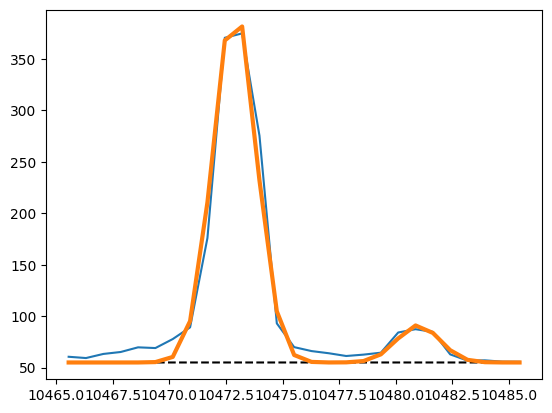

In [210]:
arc1_9532 = out_arc_9532.flatchain.arc1.mean()
arc2_9532 = out_arc_9532.flatchain.arc2.mean()
sigma_arc_9532 = out_arc_9532.flatchain.sigma.mean()

plt.plot(x_arc_9532, y_arc_9532)

plt.plot(x_arc_9532, 55 + gaussian(x_arc_9532, arc1_9532, 10472.88, 0, sigma_arc_9532), ls='--', color='black')
plt.plot(x_arc_9532, 55 + gaussian(x_arc_9532, arc2_9532, 10481, 0, sigma_arc_9532), ls='--', color='black')

plt.plot(x_arc_9532, 55 + gaussian(x_arc_9532, arc1_9532, 10472.88, 0, sigma_arc_9532) \
         + gaussian(x_arc_9532, arc2_9532, 10481, 0, sigma_arc_9532), lw=3
)

# [SIII]9069

### Arc lines

In [219]:
wave_cat['[SIII]9069']*(1 + z_BN[igal])

9957.640201000002

In [220]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_9069 = [wave_cat['[SIII]9069']*(1 + z_BN[igal]) + 80, wave_cat['[SIII]9069']*(1 + z_BN[igal]) + 100]
mask_arc_9069 = (wcal_red[21].data['wave_soln'][0] >= wlims_9069[0]) & (wcal_red[21].data['wave_soln'][0] < wlims_9069[1])

# Arc spectra around the fitted line
x_arc_9069 = wcal_red[21].data['wave_soln'][0][mask_arc_9069]
y_arc_9069 = wcal_red[21].data['spec'][0][mask_arc_9069]

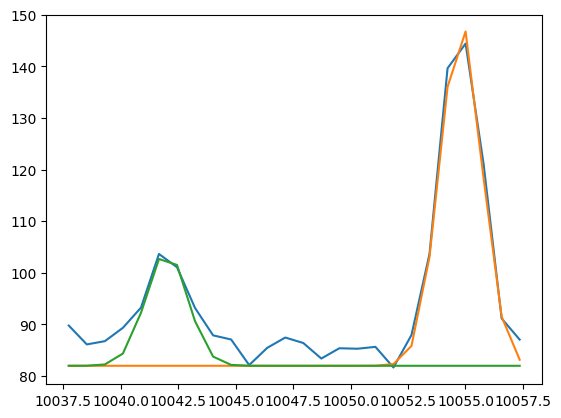

In [221]:
plt.plot(x_arc_9069, y_arc_9069)
plt.plot(x_arc_9069, 82 + gaussian(x_arc_9069, 150, 10054.8, 0, 0.9))
plt.plot(x_arc_9069, 82 + gaussian(x_arc_9069, 50, 10042, 0, 0.9))

In [222]:
params_arc_9069 = Parameters()
params_arc_9069.add('z', value=0.0, vary=False)
params_arc_9069.add('mu1', value=10054.8, vary=False)
params_arc_9069.add('mu2', value=10042, vary=False)
params_arc_9069.add('arc1', value=150, min=0.)
params_arc_9069.add('arc2', value=50, min=0.)
params_arc_9069.add('sigma', value=0.9, min=0.)
params_arc_9069.add('bkg', value=82, vary=False)

def residual_arc_9069(params_arc_9069, x, data, uncertainty):
    
    z = params_arc_9069['z']
    mu1 = params_arc_9069['mu1']
    mu2 = params_arc_9069['mu2']
    flux1 = params_arc_9069['arc1']
    flux2 = params_arc_9069['arc2']
    sigma = params_arc_9069['sigma']
    bkg = params_arc_9069['bkg']
    
    x = x_arc_9069
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model = bkg + model1 + model2
    return (model - y_arc_9069) / 10

np.random.seed(950)
out_arc_9069 = minimize(residual_arc_9069, params_arc_9069, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:18<00:00, 135.37it/s]


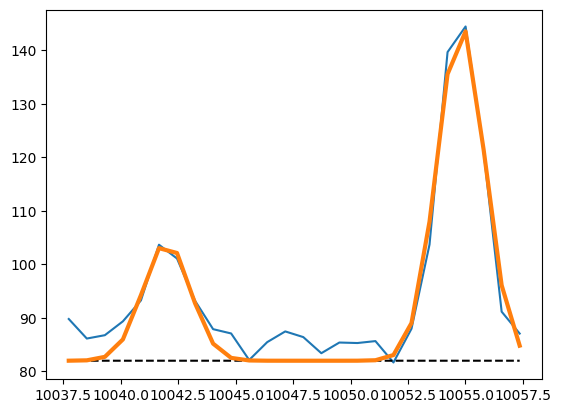

In [223]:
arc1_9069 = out_arc_9069.flatchain.arc1.mean()
arc2_9069 = out_arc_9069.flatchain.arc2.mean()
sigma_arc_9069 = out_arc_9069.flatchain.sigma.mean()

plt.plot(x_arc_9069, y_arc_9069)

plt.plot(x_arc_9069, 82 + gaussian(x_arc_9069, arc1_9069, 10054.8, 0, sigma_arc_9069), ls='--', color='black')
plt.plot(x_arc_9069, 82 + gaussian(x_arc_9069, arc2_9069, 10042, 0, sigma_arc_9069), ls='--', color='black')

plt.plot(x_arc_9069, 82 + gaussian(x_arc_9069, arc1_9069, 10054.8, 0, sigma_arc_9069) \
         + gaussian(x_arc_9069, arc2_9069, 10042, 0, sigma_arc_9069), lw=3
)

# [OI]6300 + [SIII]6312

### Arc lines

In [232]:
wave_cat['[SIII]6312']*(1 + z_BN[igal])

6930.862802100001

In [233]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_6312 = [wave_cat['[SIII]6312']*(1 + z_BN[igal]), wave_cat['[SIII]6312']*(1 + z_BN[igal]) + 20]
mask_arc_6312 = (wcal_red[15].data['wave_soln'][0] >= wlims_6312[0]) & (wcal_red[15].data['wave_soln'][0] < wlims_6312[1])

# Arc spectra around the fitted line
x_arc_6312 = wcal_red[15].data['wave_soln'][0][mask_arc_6312]
y_arc_6312 = wcal_red[15].data['spec'][0][mask_arc_6312]

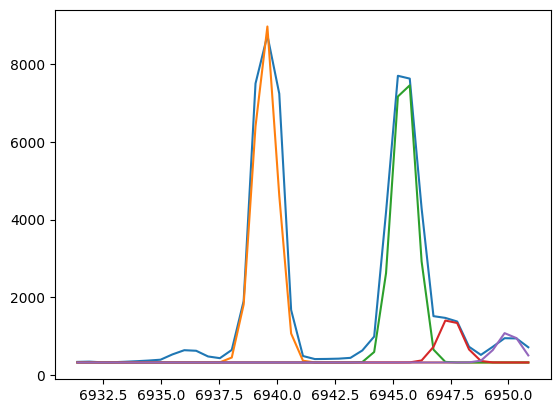

In [234]:
plt.plot(x_arc_6312, y_arc_6312)
plt.plot(x_arc_6312, 320 + gaussian(x_arc_6312, 11000, 6939.5, 0, 0.5))
plt.plot(x_arc_6312, 320 + gaussian(x_arc_6312, 10000, 6945.5, 0, 0.5))
plt.plot(x_arc_6312, 320 + gaussian(x_arc_6312, 1500, 6947.5, 0, 0.5))
plt.plot(x_arc_6312, 320 + gaussian(x_arc_6312, 1000, 6950, 0, 0.5))

In [235]:
params_arc_6312 = Parameters()
params_arc_6312.add('z', value=0.0, vary=False)
params_arc_6312.add('mu1', value=6939.5, vary=False)
params_arc_6312.add('mu2', value=6945.5, vary=False)
params_arc_6312.add('mu3', value=6947.5, vary=False)
params_arc_6312.add('mu4', value=6950, vary=False)
params_arc_6312.add('arc1', value=11000, min=0.)
params_arc_6312.add('arc2', value=10000, min=0.)
params_arc_6312.add('arc3', value=1500, min=0.)
params_arc_6312.add('arc4', value=1000, min=0.)
params_arc_6312.add('sigma', value=0.5, min=0.)
params_arc_6312.add('bkg', value=320, vary=False)

def residual_arc_6312(params_arc_6312, x, data, uncertainty):
    
    z = params_arc_6312['z']
    mu1 = params_arc_6312['mu1']
    mu2 = params_arc_6312['mu2']
    mu3 = params_arc_6312['mu3']
    mu4 = params_arc_6312['mu4']
    flux1 = params_arc_6312['arc1']
    flux2 = params_arc_6312['arc2']
    flux3 = params_arc_6312['arc3']
    flux4 = params_arc_6312['arc4']
    sigma = params_arc_6312['sigma']
    bkg = params_arc_6312['bkg']
    
    x = x_arc_6312
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model = bkg + model1 + model2 + model3 + model4
    return (model - y_arc_6312) / 10

np.random.seed(950)
out_arc_6312 = minimize(residual_arc_6312, params_arc_6312, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [00:25<00:00, 98.88it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [78.10283978 81.72449591 23.10339372 99.33720158 67.39397507]


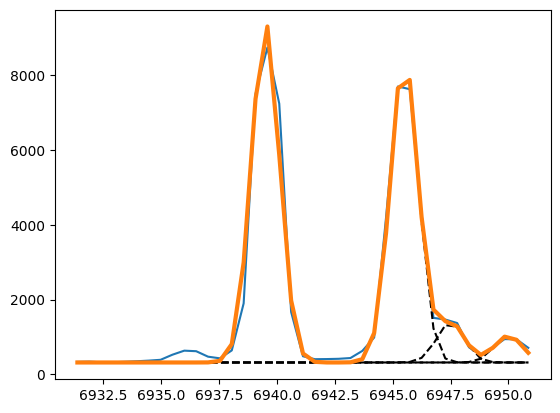

In [236]:
arc1_6312 = out_arc_6312.flatchain.arc1.mean()
arc2_6312 = out_arc_6312.flatchain.arc2.mean()
arc3_6312 = out_arc_6312.flatchain.arc3.mean()
arc4_6312 = out_arc_6312.flatchain.arc4.mean()
sigma_arc_6312 = out_arc_6312.flatchain.sigma.mean()

plt.plot(x_arc_6312, y_arc_6312)

plt.plot(x_arc_6312, 320 + gaussian(x_arc_6312, arc1_6312, 6939.5, 0, sigma_arc_6312), ls='--', color='black')
plt.plot(x_arc_6312, 320 + gaussian(x_arc_6312, arc2_6312, 6945.5, 0, sigma_arc_6312), ls='--', color='black')
plt.plot(x_arc_6312, 320 + gaussian(x_arc_6312, arc3_6312, 6947.5, 0, sigma_arc_6312), ls='--', color='black')
plt.plot(x_arc_6312, 320 + gaussian(x_arc_6312, arc4_6312, 6950, 0, sigma_arc_6312), ls='--', color='black')

plt.plot(x_arc_6312, 320 + gaussian(x_arc_6312, arc1_6312, 6939.5, 0, sigma_arc_6312) \
         + gaussian(x_arc_6312, arc2_6312, 6945.5, 0, sigma_arc_6312) \
         + gaussian(x_arc_6312, arc3_6312, 6947.5, 0, sigma_arc_6312) \
         + gaussian(x_arc_6312, arc4_6312, 6950, 0, sigma_arc_6312), lw=3
)

# [OIII]5007 + HeI 5015

### Arc lines

In [245]:
wave_cat['[OIII]5007']*(1 + z_BN[igal])

5497.688853505

In [246]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_5007 = [wave_cat['[OIII]5007']*(1 + z_BN[igal]) - 5, wave_cat['[OIII]5007']*(1 + z_BN[igal]) + 5]
mask_arc_5007 = (wcal_red[11].data['wave_soln'][0] >= wlims_5007[0]) & (wcal_red[11].data['wave_soln'][0] < wlims_5007[1])

# Arc spectra around the fitted line
x_arc_5007 = wcal_red[11].data['wave_soln'][0][mask_arc_5007]
y_arc_5007 = wcal_red[11].data['spec'][0][mask_arc_5007]

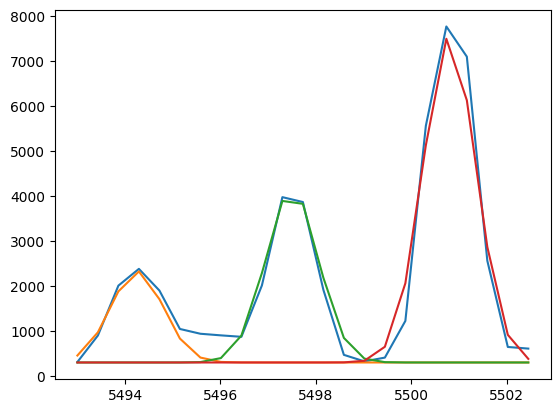

In [247]:
plt.plot(x_arc_5007, y_arc_5007)
plt.plot(x_arc_5007, 300 + gaussian(x_arc_5007, 2800, 5494.25, 0, 0.55))
plt.plot(x_arc_5007, 300 + gaussian(x_arc_5007, 5300, 5497.5, 0, 0.55))
plt.plot(x_arc_5007, 300 + gaussian(x_arc_5007, 10000, 5500.8, 0, 0.55))

In [248]:
params_arc_5007 = Parameters()
params_arc_5007.add('z', value=0.0, vary=False)
params_arc_5007.add('mu1', value=5494.25, vary=False)
params_arc_5007.add('mu2', value=5497.5, vary=False)
params_arc_5007.add('mu3', value=5500.8, vary=False)
params_arc_5007.add('arc1', value=2800, min=0.)
params_arc_5007.add('arc2', value=5300, min=0.)
params_arc_5007.add('arc3', value=10000, min=0.)
params_arc_5007.add('sigma', value=0.55, min=0.)
params_arc_5007.add('bkg', value=300, vary=False)

def residual_arc_5007(params_arc_5007, x, data, uncertainty):
    
    z = params_arc_5007['z']
    mu1 = params_arc_5007['mu1']
    mu2 = params_arc_5007['mu2']
    mu3 = params_arc_5007['mu3']
    flux1 = params_arc_5007['arc1']
    flux2 = params_arc_5007['arc2']
    flux3 = params_arc_5007['arc3']
    sigma = params_arc_5007['sigma']
    bkg = params_arc_5007['bkg']
    
    x = x_arc_5007
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = bkg + model1 + model2 + model3
    return (model - y_arc_5007) / 10

np.random.seed(950)
out_arc_5007 = minimize(residual_arc_5007, params_arc_5007, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:21<00:00, 114.46it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [53.54367454 72.44627888 31.24704429 66.18237419]


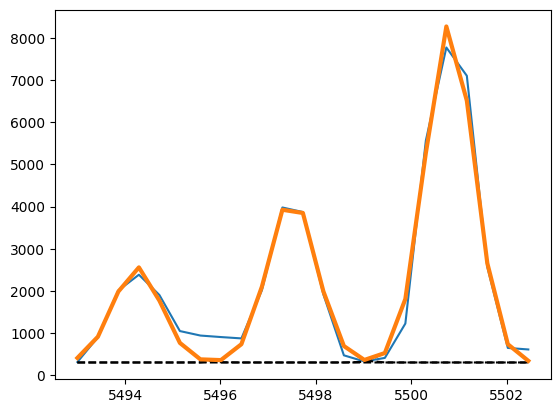

In [249]:
arc1_5007 = out_arc_5007.flatchain.arc1.mean()
arc2_5007 = out_arc_5007.flatchain.arc2.mean()
arc3_5007 = out_arc_5007.flatchain.arc3.mean()
sigma_arc_5007 = out_arc_5007.flatchain.sigma.mean()

plt.plot(x_arc_5007, y_arc_5007)

plt.plot(x_arc_5007, 300 + gaussian(x_arc_5007, arc1_5007, 5494.25, 0, sigma_arc_5007), ls='--', color='black')
plt.plot(x_arc_5007, 300 + gaussian(x_arc_5007, arc2_5007, 5497.5, 0, sigma_arc_5007), ls='--', color='black')
plt.plot(x_arc_5007, 300 + gaussian(x_arc_5007, arc3_5007, 5500.8, 0, sigma_arc_5007), ls='--', color='black')

plt.plot(x_arc_5007, 300 + gaussian(x_arc_5007, arc1_5007, 5494.25, 0, sigma_arc_5007) \
         + gaussian(x_arc_5007, arc2_5007, 5497.5, 0, sigma_arc_5007) \
         + gaussian(x_arc_5007, arc3_5007, 5500.8, 0, sigma_arc_5007), lw=3
)

# [OIII]4363

### Arc lines

In [258]:
wave_cat['[OIII]4363']*(1 + z_BN[igal])

4790.956194315

In [259]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_4363 = [wave_cat['[OIII]4363']*(1 + z_BN[igal]) - 5, wave_cat['[OIII]4363']*(1 + z_BN[igal]) + 5]
mask_arc_4363 = (wcal_red[7].data['wave_soln'][0] >= wlims_4363[0]) & (wcal_red[7].data['wave_soln'][0] < wlims_4363[1])

# Arc spectra around the fitted line
x_arc_4363 = wcal_red[7].data['wave_soln'][0][mask_arc_4363]
y_arc_4363 = wcal_red[7].data['spec'][0][mask_arc_4363]

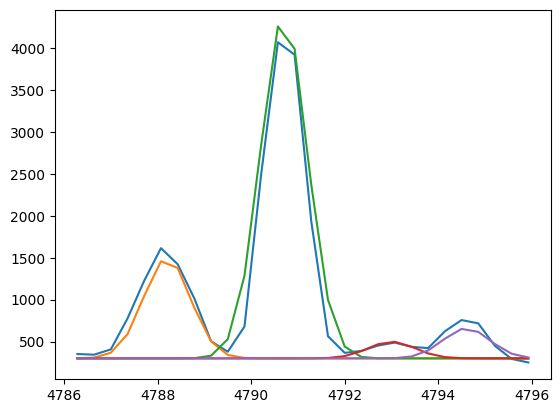

In [260]:
plt.plot(x_arc_4363, y_arc_4363)
plt.plot(x_arc_4363, 300 + gaussian(x_arc_4363, 1500, 4788.2, 0, 0.5))
plt.plot(x_arc_4363, 300 + gaussian(x_arc_4363, 5130, 4790.7, 0, 0.5))
plt.plot(x_arc_4363, 300 + gaussian(x_arc_4363,  250,   4793, 0, 0.5))
plt.plot(x_arc_4363, 300 + gaussian(x_arc_4363,  450, 4794.6, 0, 0.5))

In [261]:
params_arc_4363 = Parameters()
params_arc_4363.add('z', value=0.0, vary=False)
params_arc_4363.add('mu1', value=4788.2, vary=False)
params_arc_4363.add('mu2', value=4790.7, vary=False)
params_arc_4363.add('mu3', value=  4793, vary=False)
params_arc_4363.add('mu4', value=4794.6, vary=False)
params_arc_4363.add('arc1', value=1500, min=0.)
params_arc_4363.add('arc2', value=5130, min=0.)
params_arc_4363.add('arc3', value= 250, min=0.)
params_arc_4363.add('arc4', value= 450, min=0.)
params_arc_4363.add('sigma', value=0.5, min=0.)
params_arc_4363.add('bkg', value=300, vary=False)

def residual_arc_4363(params_arc_4363, x, data, uncertainty):
    
    z = params_arc_4363['z']
    mu1 = params_arc_4363['mu1']
    mu2 = params_arc_4363['mu2']
    mu3 = params_arc_4363['mu3']
    mu4 = params_arc_4363['mu4']
    flux1 = params_arc_4363['arc1']
    flux2 = params_arc_4363['arc2']
    flux3 = params_arc_4363['arc3']
    flux4 = params_arc_4363['arc4']
    sigma = params_arc_4363['sigma']
    bkg = params_arc_4363['bkg']
    
    x = x_arc_4363
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model = bkg + model1 + model2 + model3 + model4
    return (model - y_arc_4363) / 10

np.random.seed(950)
out_arc_4363 = minimize(residual_arc_4363, params_arc_4363, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [00:25<00:00, 99.71it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 55.50037693  75.23155355  59.21467692 119.96725021  94.23758776]


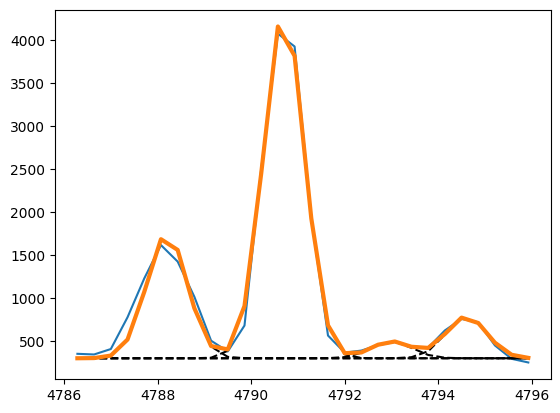

In [262]:
arc1_4363 = out_arc_4363.flatchain.arc1.mean()
arc2_4363 = out_arc_4363.flatchain.arc2.mean()
arc3_4363 = out_arc_4363.flatchain.arc3.mean()
arc4_4363 = out_arc_4363.flatchain.arc4.mean()
sigma_arc_4363 = out_arc_4363.flatchain.sigma.mean()

plt.plot(x_arc_4363, y_arc_4363)

plt.plot(x_arc_4363, 300 + gaussian(x_arc_4363, arc1_4363, 4788.2, 0, sigma_arc_4363), ls='--', color='black')
plt.plot(x_arc_4363, 300 + gaussian(x_arc_4363, arc2_4363, 4790.7, 0, sigma_arc_4363), ls='--', color='black')
plt.plot(x_arc_4363, 300 + gaussian(x_arc_4363, arc3_4363, 4793, 0, sigma_arc_4363), ls='--', color='black')
plt.plot(x_arc_4363, 300 + gaussian(x_arc_4363, arc4_4363, 4794.6, 0, sigma_arc_4363), ls='--', color='black')

plt.plot(x_arc_4363, 300 + gaussian(x_arc_4363, arc1_4363, 4788.2, 0, sigma_arc_4363) \
         + gaussian(x_arc_4363, arc2_4363, 4790.7, 0, sigma_arc_4363) \
         + gaussian(x_arc_4363, arc3_4363, 4793, 0, sigma_arc_4363) \
         + gaussian(x_arc_4363, arc4_4363, 4794.6, 0, sigma_arc_4363), lw=3
)

# Saving arc data

In [271]:
sigma_arc = np.array([sigma_arc_3729,
                      sigma_arc_hd,
                      sigma_arc_hg,
                      sigma_arc_4363,
                      sigma_arc_4471,
                      sigma_arc_4685,
                      sigma_arc_hb,
                      sigma_arc_4959,
                      sigma_arc_5007,
                      sigma_arc_5755,
                      sigma_arc_5875,
                      sigma_arc_6312,
                      sigma_arc_ha,
                      sigma_arc_6678,
                      sigma_arc_6730,
                      sigma_arc_7065,
                      sigma_arc_7330,
                      sigma_arc_9069,
                      sigma_arc_9532])

x_arc = np.array([np.median(x_arc_3729),
                  np.median(x_arc_hd),
                  np.median(x_arc_hg),
                  np.median(x_arc_4363),
                  np.median(x_arc_4471),
                  np.median(x_arc_4685),
                  np.median(x_arc_hb),
                  np.median(x_arc_4959),
                  np.median(x_arc_5007),
                  np.median(x_arc_5755),
                  np.median(x_arc_5875),
                  np.median(x_arc_6312),
                  np.median(x_arc_ha),
                  np.median(x_arc_6678),
                  np.median(x_arc_6730),
                  np.median(x_arc_7065),
                  np.median(x_arc_7330),
                  np.median(x_arc_9069),
                  np.median(x_arc_9532)])

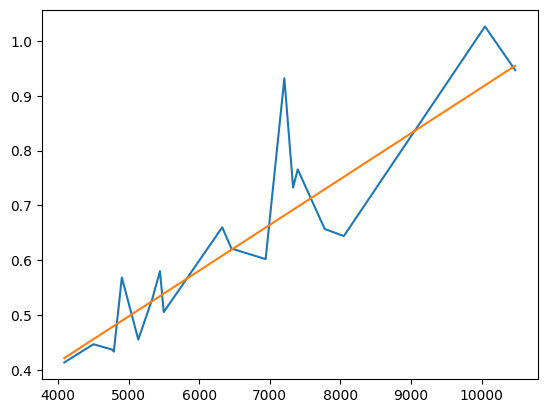

In [272]:
plt.plot(x_arc, sigma_arc)
plt.plot(x_arc, (((sigma_arc[-1] - sigma_arc[0])/(x_arc[-1] - x_arc[0])) * x_arc) + 0.08)

In [273]:
params_sigma_arc = Parameters()
params_sigma_arc.add('m', value=8.352049304985616e-05)
params_sigma_arc.add('n', value=0.08)

def residual_sigma_arc(params_sigma_arc, x, data, uncertainty):
    
    m = params_sigma_arc['m']
    n = params_sigma_arc['n']
    
    x = x_arc
    model = (m * x_arc) + n
    return (model - sigma_arc) / 0.05

np.random.seed(950)
out_sigma_arc = minimize(residual_sigma_arc, params_sigma_arc, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:10<00:00, 231.47it/s]


In [274]:
lmfit.report_fit(out_sigma_arc.params)

[[Variables]]
    m:  9.1375e-05 +/- 6.6525e-06 (7.28%) (init = 8.352049e-05)
    n:  0.04053405 +/- 0.04407090 (108.73%) (init = 0.08)
[[Correlations]] (unreported correlations are < 0.100)
    C(m, n) = -0.9655


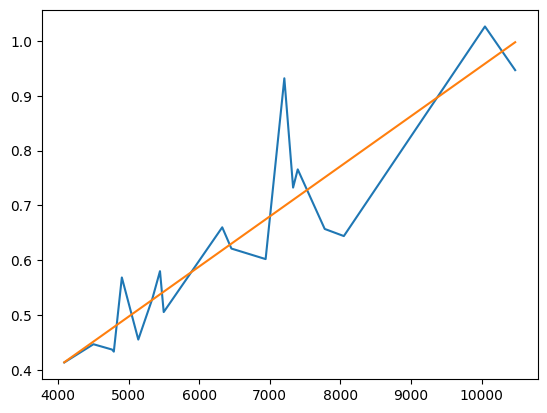

In [275]:
m = out_sigma_arc.flatchain.m.mean()
n = out_sigma_arc.flatchain.n.mean()

plt.plot(x_arc, sigma_arc)
plt.plot(x_arc, (m * x_arc) + n)